# Machine Learning Modeling for 30-Day Hospital Readmission Prediction

## Project Objective

The objective of this phase is to develop and evaluate machine learning models that predict whether a patient will be readmitted to the hospital within 30 days.

The target variable is:

`readmitted_30d`

- **0:** No readmission within 30 days
- **1:** Readmission within 30 days

The model-ready dataset was created during the previous feature engineering and feature selection phases.

### Modeling Dataset

- Total observations: **100,114**
- Final selected features: **39**
- Target variable: **1**
- Total modeling columns: **40**

### Modeling Approach

The machine learning workflow will include:

1. Loading and validating the model-ready dataset
2. Separating features and target
3. Performing a stratified train-validation-test split
4. Building a leakage-safe preprocessing pipeline
5. Establishing baseline models
6. Training advanced machine learning models
7. Addressing class imbalance
8. Hyperparameter tuning
9. Evaluating models using appropriate classification metrics
10. Selecting the final model
11. Evaluating the final model on the untouched test set
12. Interpreting feature importance and model behavior

Because the positive class represents approximately **11.34%** of the dataset, the target variable is imbalanced. Therefore, model performance will not be evaluated using accuracy alone.

## 1. Import Required Libraries

This section imports the libraries required for:

- Data manipulation
- Visualization
- Dataset splitting
- Feature preprocessing
- Machine learning modeling
- Class imbalance handling
- Hyperparameter optimization
- Model evaluation

In [44]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Model-Ready Dataset

The model-ready dataset contains the final set of features selected during the feature selection phase and the binary target variable.

The dataset is loaded independently from the processed data directory so that this notebook does not depend on variables from previous notebooks.

In [45]:
# ============================================================
# LOAD MODEL-READY DATASET
# ============================================================

DATA_PATH = Path("../Data/processed/diabetes_model_ready.csv")

df_model_Ml = pd.read_csv(DATA_PATH)

print("=" * 70)
print("MODEL-READY DATASET LOADED")
print("=" * 70)

print(f"\nDataset shape: {df_model_Ml.shape}")

print("\nFirst five rows:")
display(df_model_Ml.head())

MODEL-READY DATASET LOADED

Dataset shape: (100114, 40)

First five rows:


,race,gender,age,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,admission_source,diag_1_group,diag_2_group,diag_3_group,num_medications_active,num_medications_up,num_medications_down,num_medications_steady,weight_documented,readmitted_30d
0,Caucasian,Female,[0-10),1,Not_Documented,Pediatrics-Endocrinology,41,0,1,0,...,Physician Referral,"Endocrine, nutritional & metabolic diseases",Not_Documented,Not_Documented,0,0,0,0,0,0
1,Caucasian,Female,[10-20),3,Not_Documented,Not_Documented,59,0,18,0,...,Emergency Room,"Endocrine, nutritional & metabolic diseases","Endocrine, nutritional & metabolic diseases","Endocrine, nutritional & metabolic diseases",1,1,0,0,0,0
2,AfricanAmerican,Female,[20-30),2,Not_Documented,Not_Documented,11,5,13,2,...,Emergency Room,Pregnancy & childbirth,"Endocrine, nutritional & metabolic diseases",Supplementary factors (V-code),1,0,0,1,0,0
3,Caucasian,Male,[30-40),2,Not_Documented,Not_Documented,44,1,16,0,...,Emergency Room,Infectious & parasitic diseases,"Endocrine, nutritional & metabolic diseases",Circulatory diseases,1,1,0,0,0,0
4,Caucasian,Male,[40-50),1,Not_Documented,Not_Documented,51,0,8,0,...,Emergency Room,Neoplasms,Neoplasms,"Endocrine, nutritional & metabolic diseases",2,0,0,2,0,0


## 3. Validate the Modeling Dataset

Before splitting the dataset, basic validation checks are performed to confirm:

- The dataset contains the expected number of observations
- The expected number of features is present
- The target column exists
- The target is binary
- No duplicate columns are present
- The dataset does not contain duplicate rows

In [46]:
# ============================================================
# MODELING DATASET VALIDATION
# ============================================================

TARGET_COLUMN = "readmitted_30d"

print("=" * 70)
print("MODELING DATASET VALIDATION")
print("=" * 70)

print(f"\nDataset shape: {df_model_Ml.shape}")
print(f"Number of columns: {df_model_Ml.shape[1]}")

print("\nDuplicate rows:", df_model_Ml.duplicated().sum())
print("Duplicate columns:", df_model_Ml.columns.duplicated().sum())

print("\nTarget column exists:",
      TARGET_COLUMN in df_model_Ml.columns)

print("\nTarget values:")
print(df_model_Ml[TARGET_COLUMN].value_counts())

print("\nTarget distribution (%):")
print(
    df_model_Ml[TARGET_COLUMN]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Validation checks
assert TARGET_COLUMN in df_model_Ml.columns, \
    "ERROR — Target column is missing"

assert set(df_model_Ml[TARGET_COLUMN].unique()) == {0, 1}, \
    "ERROR — Target is not binary"

assert df_model_Ml.shape == (100114, 40), \
    "ERROR — Unexpected dataset shape"

assert df_model_Ml.columns.duplicated().sum() == 0, \
    "ERROR — Duplicate columns detected"

print("\n" + "=" * 70)
print("PASS — Dataset validation completed successfully")
print("=" * 70)

MODELING DATASET VALIDATION

Dataset shape: (100114, 40)
Number of columns: 40

Duplicate rows: 1
Duplicate columns: 0

Target column exists: True

Target values:
readmitted_30d
0    88757
1    11357
Name: count, dtype: int64

Target distribution (%):
readmitted_30d
0    88.66
1    11.34
Name: proportion, dtype: float64

PASS — Dataset validation completed successfully


## 4. Feature and Target Separation

The dataset is separated into:

- `X` — the 39 predictor variables
- `y` — the binary 30-day readmission target

The target variable is excluded from the feature matrix to prevent target leakage.

In [47]:
# ============================================================
# FEATURE AND TARGET SEPARATION
# ============================================================

TARGET_COLUMN = "readmitted_30d"

X = df_model_Ml.drop(columns=[TARGET_COLUMN]).copy()

y = df_model_Ml[TARGET_COLUMN].copy()

print("=" * 70)
print("FEATURE AND TARGET SEPARATION")
print("=" * 70)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nNumber of features: {X.shape[1]}")

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

FEATURE AND TARGET SEPARATION

Feature matrix shape: (100114, 39)
Target shape: (100114,)

Number of features: 39

Target distribution:
readmitted_30d
0    88757
1    11357
Name: count, dtype: int64

Target distribution (%):
readmitted_30d
0    88.66
1    11.34
Name: proportion, dtype: float64


## 5. Feature Type Identification

The selected features include both numerical and categorical variables.

Feature types are identified programmatically to build an appropriate preprocessing pipeline. Numerical features will be processed separately from categorical features.

In [48]:
# ============================================================
# IDENTIFY FEATURE TYPES
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("=" * 70)
print("FEATURE TYPE SUMMARY")
print("=" * 70)

print(f"\nNumerical features ({len(numerical_features)}):")
for feature in numerical_features:
    print(f"  - {feature}")

print(f"\nCategorical features ({len(categorical_features)}):")
for feature in categorical_features:
    print(f"  - {feature}")

print(f"\nTotal features: {len(numerical_features) + len(categorical_features)}")

FEATURE TYPE SUMMARY

Numerical features (13):
  - time_in_hospital
  - num_lab_procedures
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - number_diagnoses
  - num_medications_active
  - num_medications_up
  - num_medications_down
  - num_medications_steady
  - weight_documented

Categorical features (26):
  - race
  - gender
  - age
  - payer_code
  - medical_specialty
  - max_glu_serum
  - A1Cresult
  - metformin
  - repaglinide
  - nateglinide
  - glimepiride
  - glipizide
  - glyburide
  - pioglitazone
  - rosiglitazone
  - acarbose
  - insulin
  - glyburide-metformin
  - change
  - diabetesMed
  - admission_type
  - discharge_disposition
  - admission_source
  - diag_1_group
  - diag_2_group
  - diag_3_group

Total features: 39


## 6. Stratified Train, Validation, and Test Split

The dataset is divided into training, validation, and test sets.

Because the target variable is imbalanced, stratified sampling is used to preserve the proportion of 30-day readmissions across all datasets.

The split is:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

The test set will remain untouched during model selection and will be used only for final model evaluation.

In [49]:
df_patient_nbr = pd.read_csv("../Data/Processed/Diabetes_orginal_file.csv")


In [50]:
# ============================================================
# VALIDATE DATASET ALIGNMENT
# ============================================================

print("=" * 70)
print("DATASET ALIGNMENT VALIDATION")
print("=" * 70)

print("\ndf_model_Ml shape:", df_model_Ml.shape)
print("df_patient_nbr shape:", df_patient_nbr.shape)

# Extract patient identifiers
groups_pbnr= df_patient_nbr["patient_nbr"].copy()

print("\nPatient groups shape:", groups_pbnr.shape)

# Validation
assert len(df_model_Ml) == len(groups_pbnr), \
    "ERROR — Modeling dataset and patient IDs have different row counts"

assert df_model_Ml.index.equals(groups_pbnr.index), \
    "ERROR — Modeling dataset and patient IDs are not index-aligned"

print("\nPASS — Row counts are identical")
print("PASS — Row indexes are aligned")
print("PASS — Patient identifiers are ready for group-based splitting")

print("=" * 70)

DATASET ALIGNMENT VALIDATION

df_model_Ml shape: (100114, 40)
df_patient_nbr shape: (100114, 67)

Patient groups shape: (100114,)

PASS — Row counts are identical
PASS — Row indexes are aligned
PASS — Patient identifiers are ready for group-based splitting


In [51]:
# ============================================================
# DEFINE FEATURES, TARGET, AND GROUPS
# ============================================================

TARGET_COLUMN = "readmitted_30d"

# Features
X = df_model_Ml.drop(columns=[TARGET_COLUMN]).copy()

# Target
y = df_model_Ml[TARGET_COLUMN].copy()

# Patient grouping variable
groups_pbnr = df_patient_nbr["patient_nbr"].copy()

print("=" * 70)
print("FEATURE, TARGET, AND GROUP SUMMARY")
print("=" * 70)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("groups_pbnr shape:", groups_pbnr.shape)

print("\nUnique patients:", groups_pbnr.nunique())
print("Total encounters:", len(groups_pbnr))

print("\nTarget distribution:")
print(y.value_counts())

# Final validation
assert len(X) == len(y) == len(groups_pbnr), \
    "ERROR — X, y, and groups have different lengths"

assert X.index.equals(y.index), \
    "ERROR — X and y indexes are not aligned"

assert X.index.equals(groups_pbnr.index), \
    "ERROR — X and patient groups are not aligned"

assert "patient_nbr" not in X.columns, \
    "ERROR — patient_nbr must not be included as a model feature"

print("\nPASS — X, y, and groups are correctly prepared")
print("PASS — patient_nbr is excluded from model features")

print("=" * 70)

FEATURE, TARGET, AND GROUP SUMMARY

X shape: (100114, 39)
y shape: (100114,)
groups_pbnr shape: (100114,)

Unique patients: 70439
Total encounters: 100114

Target distribution:
readmitted_30d
0    88757
1    11357
Name: count, dtype: int64

PASS — X, y, and groups are correctly prepared
PASS — patient_nbr is excluded from model features


# Train-Test Split Using Patient-Level Grouping

The dataset contains multiple hospital encounters for some patients.

A standard random train-test split could place encounters from the same patient
in both the training and testing datasets. This could lead to patient-level
data leakage and overly optimistic model performance.

To prevent this, `patient_nbr` is used as a grouping variable with
`GroupShuffleSplit`.

This ensures that all encounters belonging to a particular patient are assigned
exclusively to either the training set or the testing set.

The `patient_nbr` column is used only for splitting and is not included as a
machine learning feature.

In [52]:
from sklearn.model_selection import GroupShuffleSplit



# ============================================================
# GROUP-BASED TRAIN-TEST SPLIT
# ============================================================

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups_pbnr)
)
# ============================================================
# CREATE TRAIN AND TEST DATASETS
# ============================================================

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups_pbnr.iloc[train_idx].copy()
groups_test = groups_pbnr.iloc[test_idx].copy()

In [53]:
# ============================================================
# TRAIN-TEST SPLIT SUMMARY
# ============================================================

print("=" * 70)
print("GROUP-BASED TRAIN-TEST SPLIT SUMMARY")
print("=" * 70)

print(f"\nFull dataset rows: {len(X):,}")

print(f"\nTraining rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

print(f"\nTraining percentage: {len(X_train) / len(X) * 100:.2f}%")
print(f"Testing percentage:  {len(X_test) / len(X) * 100:.2f}%")

print("\n" + "=" * 70)
print("FEATURE AND TARGET SHAPES")
print("=" * 70)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

print(f"\ny_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print("\n" + "=" * 70)
print("UNIQUE PATIENTS")
print("=" * 70)

print(f"\nTotal unique patients: {groups_pbnr.nunique():,}")
print(f"Training patients:     {groups_train.nunique():,}")
print(f"Testing patients:      {groups_test.nunique():,}")



GROUP-BASED TRAIN-TEST SPLIT SUMMARY

Full dataset rows: 100,114

Training rows: 80,039
Testing rows:  20,075

Training percentage: 79.95%
Testing percentage:  20.05%

FEATURE AND TARGET SHAPES

X_train shape: (80039, 39)
X_test shape:  (20075, 39)

y_train shape: (80039,)
y_test shape:  (20075,)

UNIQUE PATIENTS

Total unique patients: 70,439
Training patients:     56,351
Testing patients:      14,088


In [54]:
# ============================================================
# PATIENT OVERLAP VALIDATION
# ============================================================

train_patients = set(groups_train.unique())
test_patients = set(groups_test.unique())

patient_overlap = train_patients.intersection(test_patients)

print("=" * 70)
print("PATIENT OVERLAP VALIDATION")
print("=" * 70)

print(f"\nUnique training patients: {len(train_patients):,}")
print(f"Unique testing patients:  {len(test_patients):,}")
print(f"Overlapping patients:     {len(patient_overlap):,}")

assert len(patient_overlap) == 0, \
    "ERROR — Some patients appear in both training and testing data"

print("\nPASS — No patient appears in both training and testing datasets")
print("=" * 70)

PATIENT OVERLAP VALIDATION

Unique training patients: 56,351
Unique testing patients:  14,088
Overlapping patients:     0

PASS — No patient appears in both training and testing datasets


In [55]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print("=" * 70)
print("TARGET DISTRIBUTION AFTER SPLITTING")
print("=" * 70)

print("\nFULL DATASET:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nTRAINING DATA:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTESTING DATA:")
print((y_test.value_counts(normalize=True) * 100).round(2))

TARGET DISTRIBUTION AFTER SPLITTING

FULL DATASET:
readmitted_30d
0    88.66
1    11.34
Name: proportion, dtype: float64

TRAINING DATA:
readmitted_30d
0    88.69
1    11.31
Name: proportion, dtype: float64

TESTING DATA:
readmitted_30d
0    88.52
1    11.48
Name: proportion, dtype: float64


In [56]:
# ============================================================
# PATIENT LEAKAGE VALIDATION
# ============================================================

train_patients = set(groups_train)
test_patients = set(groups_test)

common_patients = train_patients.intersection(test_patients)

print("=" * 70)
print("PATIENT LEAKAGE VALIDATION")
print("=" * 70)

print(f"\nUnique patients in training set: {len(train_patients):,}")
print(f"Unique patients in testing set:  {len(test_patients):,}")

print(f"\nPatients appearing in both sets: {len(common_patients)}")

assert len(common_patients) == 0, \
    "ERROR — Patient leakage detected between training and testing sets"

print("\nPASS — No patient appears in both training and testing sets")
print("=" * 70)

PATIENT LEAKAGE VALIDATION

Unique patients in training set: 56,351
Unique patients in testing set:  14,088

Patients appearing in both sets: 0

PASS — No patient appears in both training and testing sets


# 3. Machine Learning Preprocessing Pipeline

After completing the patient-level train-test split and validating that no patient appears in both datasets, the next step is to prepare the features for machine learning.

The preprocessing pipeline will handle numerical and categorical features separately.

## Numerical Features

Numerical features will be:

1. Imputed using the median if missing values exist
2. Scaled using `StandardScaler`

## Categorical Features

Categorical features will be:

1. Imputed using the most frequent category if missing values exist
2. Encoded using `OneHotEncoder`

The transformations will be combined using `ColumnTransformer`.

All preprocessing will be fitted only on the training data to prevent data leakage. The same learned transformations will then be applied to the testing data.

In [57]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

train_missing = X_train.isnull().sum()
test_missing = X_test.isnull().sum()

print("\nTraining data missing values:")
print(train_missing[train_missing > 0])

print("\nTesting data missing values:")
print(test_missing[test_missing > 0])

print("\nTotal missing values in training data:",
      train_missing.sum())

print("Total missing values in testing data:",
      test_missing.sum())

print("=" * 70)

MISSING VALUE CHECK

Training data missing values:
Series([], dtype: int64)

Testing data missing values:
Series([], dtype: int64)

Total missing values in training data: 0
Total missing values in testing data: 0


In [58]:
# ============================================================
# IMPORT PREPROCESSING TOOLS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [59]:
# ============================================================
# NUMERICAL PREPROCESSING PIPELINE
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical preprocessing pipeline created successfully")

Numerical preprocessing pipeline created successfully


In [60]:
# ============================================================
# CATEGORICAL PREPROCESSING PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created successfully")

Categorical preprocessing pipeline created successfully


In [61]:
# ============================================================
# COMPLETE PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("=" * 70)
print("PREPROCESSING PIPELINE CREATED")
print("=" * 70)

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total original features: {len(numerical_features) + len(categorical_features)}")

PREPROCESSING PIPELINE CREATED

Numerical features: 13
Categorical features: 26
Total original features: 39


# Logistic Regression Modeling

Logistic Regression was selected as the first machine learning model for predicting whether a patient would be readmitted within 30 days.

The objective of this stage is to establish a strong and interpretable baseline before evaluating more complex machine learning models.

The target variable is:

- `0` = No readmission within 30 days
- `1` = Readmission within 30 days

The dataset is imbalanced, with approximately 11.34% of encounters resulting in a readmission within 30 days. Therefore, model evaluation focuses not only on accuracy but also on minority-class performance using precision, recall, F1-score, ROC-AUC, and Average Precision.

Because the same patient can appear in multiple hospital encounters, all model validation follows a patient-aware methodology to prevent information leakage between training and evaluation data.

## 4. Baseline Model — Dummy Classifier

Before training real machine learning models, a Dummy Classifier is used to establish a baseline.

The Dummy Classifier does not learn meaningful relationships between the features and the target. Instead, it makes predictions using a simple predefined strategy.

This baseline is important because the target variable is imbalanced:

- 0: No readmission within 30 days
- 1: Readmission within 30 days

A model must outperform the Dummy Classifier to demonstrate that it has learned useful predictive patterns.


In [62]:

#import the libray for the Dummyclassifer
from sklearn.dummy import DummyClassifier

# ============================================================
# DUMMY CLASSIFIER BASELINE
# ============================================================


dummy_model = DummyClassifier(
    strategy='most_frequent'
)

# Train baseline model

dummy_model.fit(X_train,y_train)

# Predictions
y_pred_dummy = dummy_model.predict(X_test)

print(F'y_pred_dummy :{y_pred_dummy}')
print("Dummy Classifier trained successfully")

y_pred_dummy :[0 0 0 ... 0 0 0]
Dummy Classifier trained successfully


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

dummy_accuracy = accuracy_score(
    y_test,
    y_pred_dummy
)

dummy_precision = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

dummy_f1 = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

print("=" * 70)
print("DUMMY CLASSIFIER PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:  {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")
print(f"F1 Score:  {dummy_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dummy,
        zero_division=0
    )
)

DUMMY CLASSIFIER PERFORMANCE

Accuracy:  0.8852
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17770
           1       0.00      0.00      0.00      2305

    accuracy                           0.89     20075
   macro avg       0.44      0.50      0.47     20075
weighted avg       0.78      0.89      0.83     20075



### Dummy Classifier Results

The Dummy Classifier achieved approximately 88.5% accuracy, which is close to the proportion of the majority class.

However, the model produced:

- Precision: 0.00
- Recall: 0.00
- F1-score: 0.00

This demonstrates why accuracy is not an appropriate standalone metric for this problem.

Although the dataset is imbalanced, the primary objective is to identify patients who may be readmitted within 30 days. A useful model must therefore detect the minority class rather than simply predict the majority class.

The Dummy Classifier serves as the minimum baseline for evaluating subsequent machine learning models.

In [64]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

train_missing = X_train.isnull().sum()
test_missing = X_test.isnull().sum()

print("\nTRAINING DATA")
print("-" * 70)

if train_missing.sum() == 0:
    print("PASS — No missing values found")
else:
    print(train_missing[train_missing > 0])

print("\nTESTING DATA")
print("-" * 70)

if test_missing.sum() == 0:
    print("PASS — No missing values found")
else:
    print(test_missing[test_missing > 0])

print("\nTotal missing values:")
print(f"Training: {train_missing.sum():,}")
print(f"Testing:  {test_missing.sum():,}")

print("=" * 70)

MISSING VALUE CHECK

TRAINING DATA
----------------------------------------------------------------------
PASS — No missing values found

TESTING DATA
----------------------------------------------------------------------
PASS — No missing values found

Total missing values:
Training: 0
Testing:  0


## . Logistic Regression Baseline

Logistic Regression is used as the first real machine learning model for predicting 30-day hospital readmission.

Unlike the Dummy Classifier, Logistic Regression learns relationships between the selected patient, hospital encounter, laboratory, diagnosis, and medication features and the target variable.

Because the dataset contains both numerical and categorical features, preprocessing is required before model training.

- Numerical features will be imputed and standardized.
- Categorical features will be imputed and one-hot encoded.

The preprocessing steps will be fitted only on the training data. The fitted transformations will then be applied to the testing data to prevent data leakage.

# . Logistic Regression — Baseline Model

Logistic Regression will be used as the first real machine learning baseline model.

The Dummy Classifier established a baseline accuracy of approximately 88.5%, but it predicted only the majority class and completely failed to identify 30-day readmissions.

For this project, Logistic Regression will provide:

- A simple and interpretable baseline
- Probability estimates for readmission
- A benchmark for more complex models
- A better understanding of the impact of class imbalance

Because the dataset contains both numerical and categorical features, preprocessing will be applied separately to each feature type.

The model will be evaluated primarily using:

- Precision
- Recall
- F1-score
- ROC-AUC

Accuracy will also be reported, but it will not be treated as the primary evaluation metric because the target variable is imbalanced.

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

In [66]:
# ============================================================
# LOGISTIC REGRESSION BASELINE
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)


# ============================================================
# COMPLETE LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)


# ============================================================
# TRAIN LOGISTIC REGRESSION
# ============================================================

logistic_pipeline.fit(
    X_train,
    y_train
)

print("=" * 70)
print("LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 70)

LOGISTIC REGRESSION TRAINING COMPLETED


In [67]:
# ============================================================
# GENERATE TEST SET PREDICTIONS
# ============================================================

# Class predictions
y_pred_logistic = logistic_pipeline.predict(X_test)

# Probability of readmission within 30 days
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

print("=" * 70)
print("LOGISTIC REGRESSION PREDICTIONS GENERATED")
print("=" * 70)

print("\nPrediction shape:", y_pred_logistic.shape)
print("Probability shape:", y_prob_logistic.shape)

LOGISTIC REGRESSION PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


# 5. Logistic Regression — Model Evaluation

After training the Logistic Regression model, predictions will be generated on the unseen test dataset.

The model will be evaluated using multiple metrics because the target variable is imbalanced.

Primary evaluation metrics:

- Recall — ability to identify actual 30-day readmissions
- Precision — reliability of predicted readmissions
- F1-score — balance between precision and recall
- ROC-AUC — ability to distinguish between the two classes

Accuracy will also be reported, but it should not be considered the primary metric because approximately 88.66% of observations belong to the non-readmission class.

In [68]:
# ============================================================
# LOGISTIC REGRESSION PERFORMANCE METRICS
# ============================================================

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)


print("=" * 70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

LOGISTIC REGRESSION PERFORMANCE

Accuracy:  0.6662
Precision: 0.1840
Recall:    0.5553
F1 Score:  0.2764
ROC-AUC:   0.6600

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17770
           1       0.18      0.56      0.28      2305

    accuracy                           0.67     20075
   macro avg       0.55      0.62      0.53     20075
weighted avg       0.84      0.67      0.72     20075



# 6. Logistic Regression — Confusion Matrix

A confusion matrix will be used to examine the exact classification outcomes for the 30-day readmission prediction task.

The four possible outcomes are:

- True Negative: Correctly predicted no readmission
- False Positive: Predicted readmission when no readmission occurred
- False Negative: Failed to identify an actual readmission
- True Positive: Correctly identified a 30-day readmission

For this project, special attention will be given to False Negatives because these represent actual 30-day readmissions that the model failed to identify.

In [69]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("=" * 70)
print("LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_logistic)

tn, fp, fn, tp = cm_logistic.ravel()

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

LOGISTIC REGRESSION CONFUSION MATRIX

Confusion Matrix:
[[12093  5677]
 [ 1025  1280]]

Classification Breakdown:
True Negatives:  12,093
False Positives: 5,677
False Negatives: 1,025
True Positives:  1,280


<Figure size 800x600 with 0 Axes>

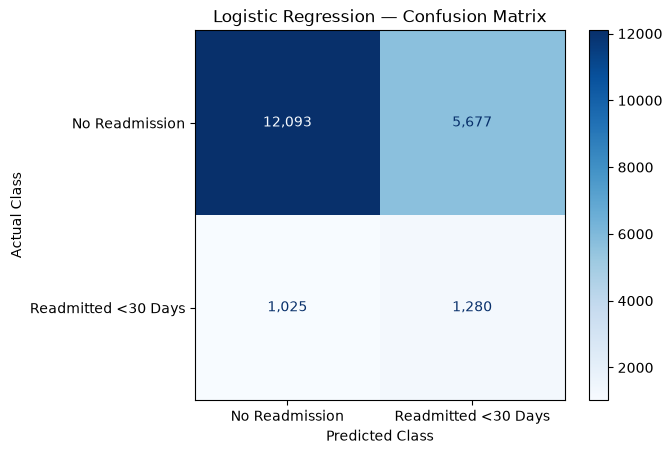

In [70]:
# ============================================================
# VISUAL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=[
        "No Readmission",
        "Readmitted <30 Days"
    ],
    values_format=",",
    cmap="Blues"
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## 2. Standard Logistic Regression

A standard Logistic Regression model was trained as the first statistical machine learning baseline.

Logistic Regression estimates the probability that a patient will belong to the positive class, representing readmission within 30 days.

The initial model was trained without class weighting using the default classification threshold of 0.50.

This experiment allows us to evaluate how a standard classifier performs on the naturally imbalanced dataset before applying any imbalance-handling techniques.

In [71]:
# ============================================================
# STANDARD LOGISTIC REGRESSION
# WITHOUT CLASS BALANCING
# ============================================================

logistic_model_standard = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=42
)

# ============================================================
# STANDARD LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline_standard = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model_standard
        )
    ]
)

# Train standard Logistic Regression

logistic_pipeline_standard.fit(
    X_train,
    y_train
)

print("=" * 70)
print("STANDARD LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 70)

STANDARD LOGISTIC REGRESSION TRAINING COMPLETED


In [72]:
# Predictions

y_pred_standard = logistic_pipeline_standard.predict(X_test)

y_prob_standard = logistic_pipeline_standard.predict_proba(X_test)[:, 1]


print("=" * 70)
print("LOGISTIC REGRESSION PREDICTIONS GENERATED")
print("=" * 70)

print("\nPrediction shape:", y_pred_standard.shape)
print("Probability shape:", y_prob_standard.shape)

# ============================================================
# LOGISTIC REGRESSION PERFORMANCE METRICS
# ============================================================

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_standard
)

logistic_precision = precision_score(
    y_test,
    y_pred_standard,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_standard,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_standard,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_standard
)


print("=" * 70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")




LOGISTIC REGRESSION PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)
LOGISTIC REGRESSION PERFORMANCE

Accuracy:  0.8855
Precision: 0.5574
Recall:    0.0148
F1 Score:  0.0287
ROC-AUC:   0.6580


In [73]:

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_standard,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17770
           1       0.56      0.01      0.03      2305

    accuracy                           0.89     20075
   macro avg       0.72      0.51      0.48     20075
weighted avg       0.85      0.89      0.83     20075



### Standard Logistic Regression Results

The standard Logistic Regression model achieved high accuracy because the majority of observations belong to the non-readmission class.

However, its minority-class performance was poor.

Test set performance:

- Accuracy: approximately 88.55%
- Precision: approximately 55.74%
- Recall: approximately 1.48%
- F1-score: approximately 2.87%
- ROC-AUC: approximately 0.658

The model identified very few patients who were actually readmitted within 30 days.

Although the model achieved relatively strong precision when predicting a positive case, the extremely low recall means that most actual readmissions were missed.

This indicates that the default decision boundary of 0.50 is too conservative for the minority class in this imbalanced classification problem.

In [74]:
# ============================================================
# STANDARD LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

cm_standard = confusion_matrix(
    y_test,
    y_pred_standard
)

tn_std, fp_std, fn_std, tp_std = cm_standard.ravel()

print("=" * 70)
print("STANDARD LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_standard)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn_std:,}")
print(f"False Positives: {fp_std:,}")
print(f"False Negatives: {fn_std:,}")
print(f"True Positives:  {tp_std:,}")


STANDARD LOGISTIC REGRESSION CONFUSION MATRIX

Confusion Matrix:
[[17743    27]
 [ 2271    34]]

Classification Breakdown:
True Negatives:  17,743
False Positives: 27
False Negatives: 2,271
True Positives:  34


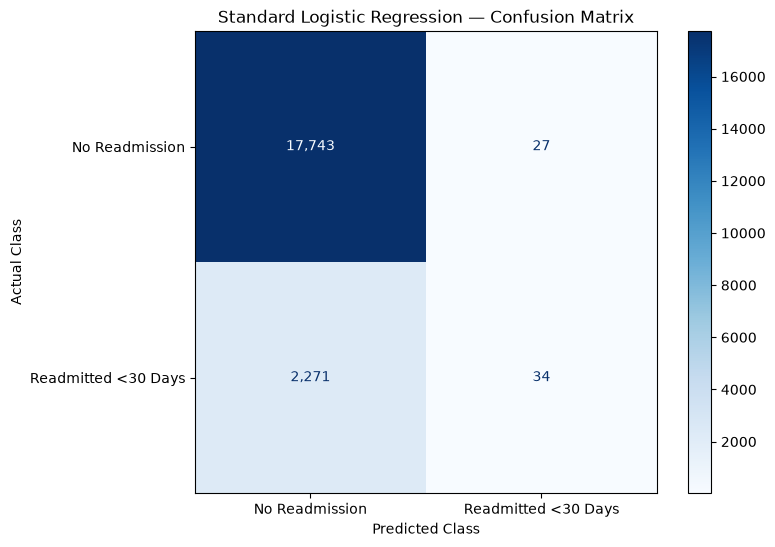

In [75]:
# ============================================================
# VISUAL CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_standard,
    display_labels=[
        "No Readmission",
        "Readmitted <30 Days"
    ],
    values_format=",",
    cmap="Blues",
    ax=ax
)

ax.set_title("Standard Logistic Regression — Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.show()

### Standard Logistic Regression Confusion Matrix

The confusion matrix showed that the standard Logistic Regression model correctly classified most non-readmission cases.

However, it identified only a very small number of actual 30-day readmissions.

This result reinforces that high accuracy does not necessarily indicate a useful predictive model when the target classes are highly imbalanced.

The model's ROC-AUC score of approximately 0.66 suggests that it does learn some predictive signal and has moderate ability to rank patients by readmission risk.

Therefore, rather than discarding Logistic Regression entirely, the next experiment evaluates whether balancing the class weights can improve minority-class detection.

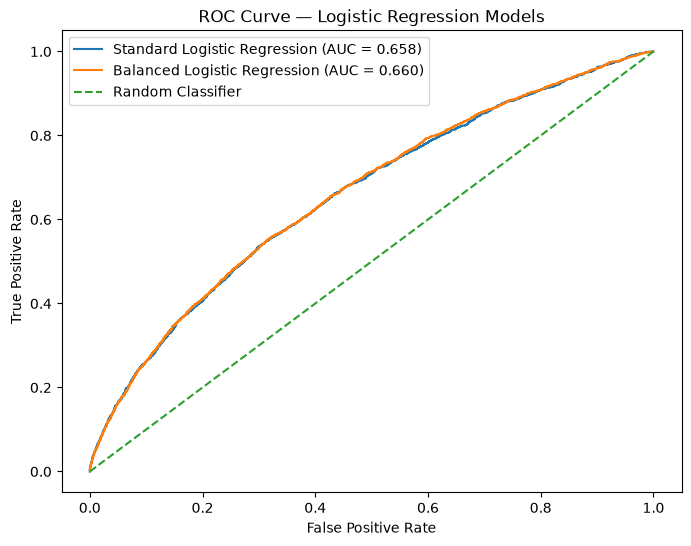

In [76]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt


# ============================================================
# ROC CURVE
# ============================================================

# Standard Logistic Regression
fpr_standard, tpr_standard, _ = roc_curve(
    y_test,
    y_prob_standard
)

auc_standard = roc_auc_score(
    y_test,
    y_prob_standard
)


# Balanced Logistic Regression
fpr_balanced, tpr_balanced, _ = roc_curve(
    y_test,
    y_prob_logistic
)

auc_balanced = roc_auc_score(
    y_test,
    y_prob_logistic
)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_standard,
    tpr_standard,
    label=f"Standard Logistic Regression (AUC = {auc_standard:.3f})"
)

plt.plot(
    fpr_balanced,
    tpr_balanced,
    label=f"Balanced Logistic Regression (AUC = {auc_balanced:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression Models")

plt.legend()
plt.show()

## 3. ROC Curve and Precision-Recall Curve

Two probability-based evaluation curves were used to further assess the standard Logistic Regression model.

### ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the trade-off between:

- True Positive Rate (Recall)
- False Positive Rate

The Area Under the ROC Curve (ROC-AUC) measures the model's ability to rank positive observations higher than negative observations across different classification thresholds.

### Precision-Recall Curve

Because the dataset is imbalanced, the Precision-Recall curve provides an additional and more focused evaluation of performance for the minority class.

It illustrates the trade-off between:

- Precision
- Recall

The Average Precision score summarizes the Precision-Recall curve into a single metric.

These curves are especially important because model performance can change substantially depending on the classification threshold.

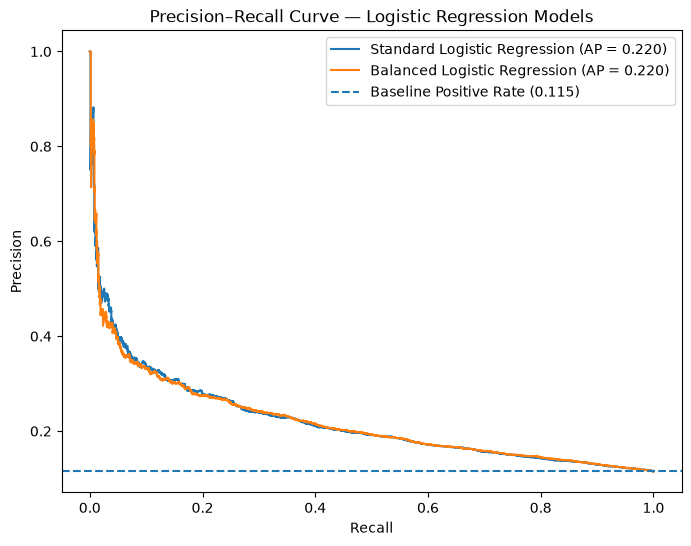

In [77]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

# Standard Logistic Regression
precision_standard, recall_standard, _ = precision_recall_curve(
    y_test,
    y_prob_standard
)

ap_standard = average_precision_score(
    y_test,
    y_prob_standard
)


# Balanced Logistic Regression
precision_balanced, recall_balanced, _ = precision_recall_curve(
    y_test,
    y_prob_logistic
)

ap_balanced = average_precision_score(
    y_test,
    y_prob_logistic
)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_standard,
    precision_standard,
    label=f"Standard Logistic Regression (AP = {ap_standard:.3f})"
)

plt.plot(
    recall_balanced,
    precision_balanced,
    label=f"Balanced Logistic Regression (AP = {ap_balanced:.3f})"
)

# Baseline positive rate
baseline = y_test.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline Positive Rate ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Logistic Regression Models")

plt.legend()
plt.show()

## 4. Patient-Aware Cross-Validation

Standard cross-validation could allow multiple encounters from the same patient to appear in both the training and validation folds.

This would create patient-level data leakage because the model could indirectly learn information about a patient during training and then evaluate on another encounter from that same patient.

To prevent this, 5-fold `StratifiedGroupKFold` cross-validation was used.

The validation strategy:

- Stratifies the target distribution across folds.
- Groups observations using `patient_nbr`.
- Ensures that the same patient cannot appear in both the training and validation portion of a fold.
- Provides a more realistic estimate of model generalization to unseen patients.

Each fold was validated to confirm that patient overlap between training and validation sets was zero.

In [78]:
from sklearn.model_selection import StratifiedGroupKFold

# ============================================================
# 5-FOLD STRATIFIED GROUP CROSS-VALIDATION
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("=" * 70)
print("5-FOLD STRATIFIED GROUP CROSS-VALIDATION CREATED")
print("=" * 70)

print("Number of folds:", sgkf.n_splits)
print("Grouping variable: patient_nbr")
print("Stratification target: readmitted_30d")

5-FOLD STRATIFIED GROUP CROSS-VALIDATION CREATED
Number of folds: 5
Grouping variable: patient_nbr
Stratification target: readmitted_30d


In [79]:
# ============================================================
# CROSS-VALIDATION FOLD VALIDATION
# ============================================================

print("=" * 70)
print("5-FOLD PATIENT LEAKAGE VALIDATION")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    # Get patients in each part of the fold
    fold_train_patients = set(groups_train.iloc[train_idx])
    fold_val_patients = set(groups_train.iloc[val_idx])

    # Check overlap
    patient_overlap = (
        fold_train_patients
        .intersection(fold_val_patients)
    )

    print(f"\nFOLD {fold}")
    print("-" * 70)

    print("Training rows:", len(train_idx))
    print("Validation rows:", len(val_idx))

    print("Training patients:", f"{len(fold_train_patients):,}")
    print("Validation patients:", f"{len(fold_val_patients):,}")

    print(
        "Training positive rate:",
        round(y_train.iloc[train_idx].mean() * 100, 2),
        "%"
    )

    print(
        "Validation positive rate:",
        round(y_train.iloc[val_idx].mean() * 100, 2),
        "%"
    )

    print(
        "Patient overlap:",
        len(patient_overlap)
    )

    assert len(patient_overlap) == 0, \
        f"ERROR — Patient leakage detected in Fold {fold}"

    print("PASS — No patient leakage")

5-FOLD PATIENT LEAKAGE VALIDATION

FOLD 1
----------------------------------------------------------------------
Training rows: 64033
Validation rows: 16006
Training patients: 45,047
Validation patients: 11,304
Training positive rate: 11.31 %
Validation positive rate: 11.31 %
Patient overlap: 0
PASS — No patient leakage

FOLD 2
----------------------------------------------------------------------
Training rows: 64027
Validation rows: 16012
Training patients: 45,080
Validation patients: 11,271
Training positive rate: 11.31 %
Validation positive rate: 11.32 %
Patient overlap: 0
PASS — No patient leakage

FOLD 3
----------------------------------------------------------------------
Training rows: 64031
Validation rows: 16008
Training patients: 45,064
Validation patients: 11,287
Training positive rate: 11.31 %
Validation positive rate: 11.31 %
Patient overlap: 0
PASS — No patient leakage

FOLD 4
----------------------------------------------------------------------
Training rows: 64033
Va

In [80]:
# ============================================================
# STANDARD LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight=None,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [81]:
print("=" * 70)
print("LOGISTIC REGRESSION PIPELINE CREATED")
print("=" * 70)

print(logistic_pipeline)

LOGISTIC REGRESSION PIPELINE CREATED
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                         

In [82]:
# ============================================================
# 5-FOLD GROUPED CROSS-VALIDATION
# STANDARD LOGISTIC REGRESSION
# ============================================================
from sklearn.base import clone

cv_results = []

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: STANDARD LOGISTIC REGRESSION")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create a fresh pipeline for each fold
    # --------------------------------------------------------

    model = clone(logistic_pipeline)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_fold,
        y_train_fold
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_val_fold)

    y_prob = model.predict_proba(X_val_fold)[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    fold_metrics = {
        "fold": fold,
        "accuracy": accuracy_score(
            y_val_fold,
            y_pred
        ),
        "precision": precision_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_val_fold,
            y_prob
        ),
        "average_precision": average_precision_score(
            y_val_fold,
            y_prob
        )
    }

    cv_results.append(fold_metrics)

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_metrics['roc_auc']:.4f} | "
        f"Recall: {fold_metrics['recall']:.4f} | "
        f"F1: {fold_metrics['f1_score']:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: STANDARD LOGISTIC REGRESSION

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6688 | Recall: 0.0199 | F1: 0.0382

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6668 | Recall: 0.0177 | F1: 0.0340

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6553 | Recall: 0.0122 | F1: 0.0236

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6666 | Recall: 0.0271 | F1: 0.0513

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6612 | Recall: 0.0149 | F1: 0.0289


In [83]:
# ============================================================
# CROSS-VALIDATION RESULTS
# ============================================================

cv_results_df = pd.DataFrame(cv_results)

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df.round(4)
)



5-FOLD CROSS-VALIDATION RESULTS


,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.8867,0.4800,0.0199,0.0382,0.6688,0.2236
1,2,0.8864,0.4507,0.0177,0.0340,0.6668,0.2190
2,3,0.8864,0.4231,0.0122,0.0236,0.6553,0.2029
3,4,0.8869,0.4949,0.0271,0.0513,0.6666,0.2239
4,5,0.8867,0.4655,0.0149,0.0289,0.6612,0.2054


In [84]:
# ============================================================
# CROSS-VALIDATION SUMMARY
# ============================================================

cv_summary = pd.DataFrame({
    "Mean": cv_results_df.drop(columns="fold").mean(),
    "Std": cv_results_df.drop(columns="fold").std()
})

cv_summary["Mean ± Std"] = (
    cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + cv_summary["Std"].round(4).astype(str)
)

print("=" * 70)
print("STANDARD LOGISTIC REGRESSION — CV SUMMARY")
print("=" * 70)

display(cv_summary)

STANDARD LOGISTIC REGRESSION — CV SUMMARY


,Mean,Std,Mean ± Std
accuracy,0.886618,0.000197,0.8866 ± 0.0002
precision,0.462850,0.027663,0.4628 ± 0.0277
recall,0.018339,0.005681,0.0183 ± 0.0057
f1_score,0.035212,0.010539,0.0352 ± 0.0105
roc_auc,0.663757,0.005479,0.6638 ± 0.0055
average_precision,0.214988,0.010097,0.215 ± 0.0101


### Standard Logistic Regression Cross-Validation Results

The standard Logistic Regression model was evaluated using 5-fold patient-aware cross-validation.

Mean performance across the five folds:

- Accuracy: 0.8866 ± 0.0002
- Precision: 0.4628 ± 0.0277
- Recall: 0.0183 ± 0.0057
- F1-score: 0.0352 ± 0.0105
- ROC-AUC: 0.6638 ± 0.0055
- Average Precision: 0.2150 ± 0.0101

The ROC-AUC and Average Precision scores were relatively stable across folds, indicating that the model consistently learns a moderate level of predictive signal.

However, the consistently low recall confirms that the standard classification configuration fails to identify most 30-day readmissions.

## 5. Balanced Logistic Regression

The dataset contains substantially fewer positive readmission cases than negative cases.

To address this class imbalance, a second Logistic Regression model was trained using:

`class_weight="balanced"`

This approach automatically assigns higher importance to the minority class during model training.

The purpose is not necessarily to improve overall accuracy, but to increase the model's ability to detect patients who are likely to be readmitted within 30 days.

The same preprocessing approach, patient-aware train-test split, and 5-fold `StratifiedGroupKFold` validation strategy were used to ensure a fair comparison with the standard Logistic Regression model.

In [85]:
# ============================================================
# BALANCED LOGISTIC REGRESSION PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION PIPELINE CREATED")
print("=" * 70)

print("\nClass weight: balanced")
print("Cross-validation: 5-fold StratifiedGroupKFold")
print("Patient grouping: preserved")

BALANCED LOGISTIC REGRESSION PIPELINE CREATED

Class weight: balanced
Cross-validation: 5-fold StratifiedGroupKFold
Patient grouping: preserved


In [86]:
# ============================================================
# 5-FOLD GROUPED CROSS-VALIDATION
# BALANCED LOGISTIC REGRESSION
# ============================================================

balanced_cv_results = []

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BALANCED LOGISTIC REGRESSION")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create fresh model for each fold
    # --------------------------------------------------------

    model = clone(balanced_logistic_pipeline)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_fold,
        y_train_fold
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_val_fold)

    y_prob = model.predict_proba(X_val_fold)[:, 1]

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    fold_metrics = {
        "fold": fold,
        "accuracy": accuracy_score(y_val_fold, y_pred),
        "precision": precision_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_val_fold,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_val_fold,
            y_prob
        ),
        "average_precision": average_precision_score(
            y_val_fold,
            y_prob
        )
    }

    balanced_cv_results.append(fold_metrics)

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_metrics['roc_auc']:.4f} | "
        f"Recall: {fold_metrics['recall']:.4f} | "
        f"F1: {fold_metrics['f1_score']:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: BALANCED LOGISTIC REGRESSION

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6687 | Recall: 0.5569 | F1: 0.2753

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6701 | Recall: 0.5679 | F1: 0.2792

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6573 | Recall: 0.5414 | F1: 0.2708

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6683 | Recall: 0.5580 | F1: 0.2703

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6633 | Recall: 0.5470 | F1: 0.2688


In [87]:
# ============================================================
# BALANCED LOGISTIC REGRESSION CV RESULTS
# ============================================================

balanced_cv_results_df = pd.DataFrame(balanced_cv_results)

print("\n" + "=" * 70)
print("BALANCED LOGISTIC REGRESSION")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    balanced_cv_results_df.round(4)
)


BALANCED LOGISTIC REGRESSION
5-FOLD CROSS-VALIDATION RESULTS


,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.6684,0.1828,0.5569,0.2753,0.6687,0.2224
1,2,0.6682,0.1851,0.5679,0.2792,0.6701,0.2195
2,3,0.6703,0.1805,0.5414,0.2708,0.6573,0.2032
3,4,0.6594,0.1784,0.5580,0.2703,0.6683,0.2234
4,5,0.6635,0.1782,0.5470,0.2688,0.6633,0.2058


In [88]:
# ============================================================
# BALANCED LOGISTIC REGRESSION CV SUMMARY
# ============================================================

balanced_cv_summary = pd.DataFrame({
    "Mean": balanced_cv_results_df
        .drop(columns="fold")
        .mean(),

    "Std": balanced_cv_results_df
        .drop(columns="fold")
        .std()
})

balanced_cv_summary["Mean ± Std"] = (
    balanced_cv_summary["Mean"]
        .round(4)
        .astype(str)
    + " ± "
    + balanced_cv_summary["Std"]
        .round(4)
        .astype(str)
)

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION — CV SUMMARY")
print("=" * 70)

display(balanced_cv_summary)

BALANCED LOGISTIC REGRESSION — CV SUMMARY


,Mean,Std,Mean ± Std
accuracy,0.665950,0.004456,0.666 ± 0.0045
precision,0.181005,0.002975,0.181 ± 0.003
recall,0.554239,0.010299,0.5542 ± 0.0103
f1_score,0.272880,0.004288,0.2729 ± 0.0043
roc_auc,0.665540,0.005275,0.6655 ± 0.0053
average_precision,0.214842,0.009601,0.2148 ± 0.0096


### Balanced Logistic Regression Cross-Validation Results

Mean performance across the 5-fold patient-aware cross-validation:

- Accuracy: 0.6660 ± 0.0045
- Precision: 0.1810 ± 0.0030
- Recall: 0.5542 ± 0.0103
- F1-score: 0.2729 ± 0.0043
- ROC-AUC: 0.6655 ± 0.0053
- Average Precision: 0.2148 ± 0.0096

The most significant improvement was observed in recall.

Compared with the standard Logistic Regression model, recall increased from approximately 1.8% to 55.4%.

The ROC-AUC and Average Precision scores remained similar, suggesting that class weighting primarily changed the decision boundary and classification behavior rather than substantially increasing the underlying ranking ability of the model.

The results were also stable across the five patient-grouped folds.

In [89]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# FINAL TRAINING ON FULL TRAINING DATA
# ============================================================

from sklearn.base import clone

final_balanced_logistic_model = clone(
    balanced_logistic_pipeline
)

final_balanced_logistic_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("FINAL BALANCED LOGISTIC REGRESSION TRAINING COMPLETED")
print("=" * 70)
print(f"\nTraining samples: {X_train.shape[0]:,}")
print(f"Training features: {X_train.shape[1]}")

FINAL BALANCED LOGISTIC REGRESSION TRAINING COMPLETED

Training samples: 80,039
Training features: 39


In [90]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# TEST SET PREDICTIONS
# ============================================================

y_pred_balanced = final_balanced_logistic_model.predict(
    X_test
)

y_prob_balanced = final_balanced_logistic_model.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION PREDICTIONS GENERATED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_balanced.shape}")
print(f"Probability shape: {y_prob_balanced.shape}")

BALANCED LOGISTIC REGRESSION PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


In [91]:
# ============================================================
# BALANCED LOGISTIC REGRESSION PERFORMANCE
# ============================================================

balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

balanced_precision = precision_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_recall = recall_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

balanced_roc_auc = roc_auc_score(
    y_test,
    y_prob_balanced
)

balanced_avg_precision = average_precision_score(
    y_test,
    y_prob_balanced
)

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:          {balanced_accuracy:.4f}")
print(f"Precision:         {balanced_precision:.4f}")
print(f"Recall:            {balanced_recall:.4f}")
print(f"F1 Score:          {balanced_f1:.4f}")
print(f"ROC-AUC:           {balanced_roc_auc:.4f}")
print(f"Average Precision: {balanced_avg_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        digits=4,
        zero_division=0
    )
)

BALANCED LOGISTIC REGRESSION PERFORMANCE

Accuracy:          0.6662
Precision:         0.1840
Recall:            0.5553
F1 Score:          0.2764
ROC-AUC:           0.6600
Average Precision: 0.2196

Classification Report:
              precision    recall  f1-score   support

           0     0.9219    0.6805    0.7830     17770
           1     0.1840    0.5553    0.2764      2305

    accuracy                         0.6662     20075
   macro avg     0.5529    0.6179    0.5297     20075
weighted avg     0.8371    0.6662    0.7249     20075



### Balanced Logistic Regression Test Results

After cross-validation, the Balanced Logistic Regression model was trained on the complete training dataset and evaluated on the untouched test set.

Test set performance:

- Accuracy: 66.62%
- Precision: 18.40%
- Recall: 55.53%
- F1-score: 27.64%
- ROC-AUC: 0.6600
- Average Precision: 0.2196

The test set results closely match the cross-validation results.

This consistency indicates that the model generalizes reasonably well to the unseen patient group and that the cross-validation estimate was reliable.

In [92]:
# ============================================================
# BALANCED LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

tn, fp, fn, tp = cm_balanced.ravel()

print("=" * 70)
print("BALANCED LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_balanced)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BALANCED LOGISTIC REGRESSION CONFUSION MATRIX

Confusion Matrix:
[[12093  5677]
 [ 1025  1280]]

Classification Breakdown:
True Negatives:  12,093
False Positives: 5,677
False Negatives: 1,025
True Positives:  1,280


### Confusion Matrix Interpretation

The Balanced Logistic Regression model produced:

- True Negatives: 12,093
- False Positives: 5,677
- False Negatives: 1,025
- True Positives: 1,280

Out of 2,305 actual 30-day readmissions in the test set, the model correctly identified 1,280 cases.

However, the model also generated a substantial number of false positive predictions.

This reflects the trade-off introduced by class weighting:

- The model detects substantially more actual readmissions.
- The number of false positive alerts increases.
- Overall accuracy decreases.

For a potential healthcare screening or risk-identification scenario, higher recall may be more valuable than accuracy alone because failing to identify a potentially high-risk patient can be costly.

The appropriate balance between recall and precision should ultimately depend on the operational or clinical cost associated with false positives and false negatives.

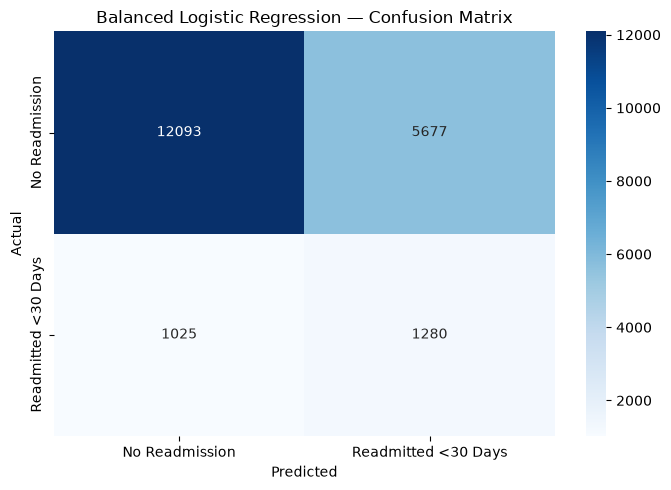

In [93]:
# ============================================================
# BALANCED LOGISTIC REGRESSION
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission", "Readmitted <30 Days"],
    yticklabels=["No Readmission", "Readmitted <30 Days"]
)

plt.title("Balanced Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## 6. Baseline Model Comparison

The initial baseline experiments compare three approaches:

1. Dummy Classifier
2. Standard Logistic Regression
3. Balanced Logistic Regression

The comparison focuses primarily on the ability to identify the minority class: patients readmitted within 30 days.

Accuracy is included for completeness but is not considered the primary model selection metric because of the class imbalance.

The key metrics for this stage are:

- Recall
- F1-score
- ROC-AUC
- Average Precision

The results establish a baseline for evaluating more complex machine learning models in the next stages.

## Logistic Regression Modeling Conclusion

The Logistic Regression experiments established an important baseline for the readmission prediction problem.

The Dummy Classifier demonstrated that accuracy alone is misleading because predicting the majority class can achieve approximately 88% accuracy while completely failing to identify 30-day readmissions.

The standard Logistic Regression model achieved moderate discrimination, with a ROC-AUC of approximately 0.66, but detected very few positive cases when using the default classification threshold.

Applying balanced class weights substantially improved minority-class detection. The Balanced Logistic Regression model achieved approximately 55.5% recall on the untouched test set and produced results consistent with patient-aware cross-validation.

However, this improvement came at the cost of lower precision and a larger number of false positives.

Therefore, Balanced Logistic Regression is retained as the primary linear baseline model for comparison against more complex non-linear models.

The next stage of the project will evaluate tree-based models to determine whether non-linear relationships and feature interactions can improve readmission prediction performance.

# Decision Tree Modeling

Decision Tree Classifier is the first tree-based model evaluated for predicting 30-day hospital readmission.

Unlike Logistic Regression, a Decision Tree can capture non-linear relationships and interactions between features. This may help identify more complex patterns associated with patient readmission.

The initial Decision Tree model will be trained using default parameters as a baseline. Hyperparameter tuning will be performed later only after evaluating the baseline performance.

The same patient-aware train-test split and 5-fold `StratifiedGroupKFold` cross-validation strategy will be maintained to ensure that no patient appears in both training and validation data.

## 1. Baseline Decision Tree Pipeline

The Decision Tree model will use the same feature preprocessing approach used in the Logistic Regression experiments.

Numerical features are passed through without scaling because Decision Trees are not sensitive to feature scale.

Categorical features are transformed using One-Hot Encoding. Unknown categories are ignored during evaluation to ensure the model can process unseen categories safely.

The initial model uses default hyperparameters to establish a tree-based baseline.


In [94]:
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# BASELINE DECISION TREE PIPELINE
# ============================================================

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

print("=" * 70)
print("BASELINE DECISION TREE PIPELINE CREATED")
print("=" * 70)

# ============================================================
# TRAIN BASELINE DECISION TREE
# ============================================================

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("=" * 70)
print("BASELINE DECISION TREE TRAINING COMPLETED")
print("=" * 70)

# ============================================================
# BASELINE DECISION TREE PREDICTIONS
# ============================================================

y_pred_tree = decision_tree_pipeline.predict(
    X_test
)

y_prob_tree = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("BASELINE DECISION TREE PREDICTIONS GENERATED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_tree.shape}")
print(f"Probability shape: {y_prob_tree.shape}")

# ============================================================
# BASELINE DECISION TREE PERFORMANCE
# ============================================================

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

tree_avg_precision = average_precision_score(
    y_test,
    y_prob_tree
)

print("=" * 70)
print("BASELINE DECISION TREE PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:          {tree_accuracy:.4f}")
print(f"Precision:         {tree_precision:.4f}")
print(f"Recall:            {tree_recall:.4f}")
print(f"F1 Score:          {tree_f1:.4f}")
print(f"ROC-AUC:           {tree_roc_auc:.4f}")
print(f"Average Precision: {tree_avg_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree,
        digits=4,
        zero_division=0
    )
)

print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BASELINE DECISION TREE PIPELINE CREATED
BASELINE DECISION TREE TRAINING COMPLETED
BASELINE DECISION TREE PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)
BASELINE DECISION TREE PERFORMANCE

Accuracy:          0.8003
Precision:         0.1523
Recall:            0.1618
F1 Score:          0.1569
ROC-AUC:           0.5225
Average Precision: 0.1209

Classification Report:
              precision    recall  f1-score   support

           0     0.8904    0.8832    0.8868     17770
           1     0.1523    0.1618    0.1569      2305

    accuracy                         0.8003     20075
   macro avg     0.5213    0.5225    0.5218     20075
weighted avg     0.8056    0.8003    0.8030     20075

False Positives: 5,677
False Negatives: 1,025
True Positives:  1,280


In [95]:
# ============================================================
# BASELINE DECISION TREE CONFUSION MATRIX
# ============================================================

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

tn, fp, fn, tp = cm_tree.ravel()

print("=" * 70)
print("BASELINE DECISION TREE CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_tree)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")

BASELINE DECISION TREE CONFUSION MATRIX

Confusion Matrix:
[[15694  2076]
 [ 1932   373]]

Classification Breakdown:
True Negatives:  15,694


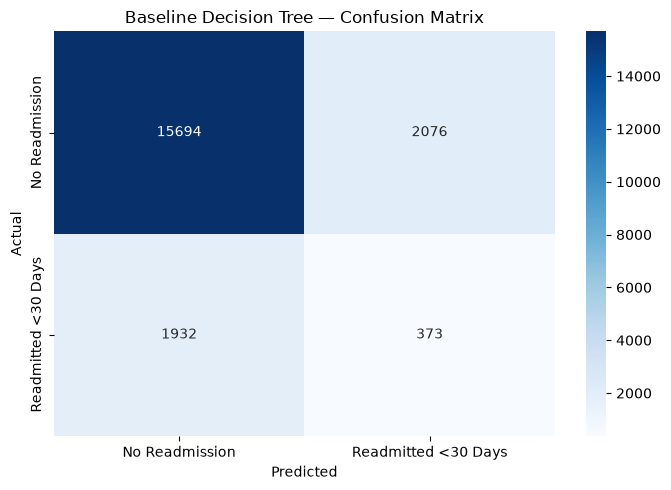

In [96]:
# ============================================================
# BASELINE DECISION TREE
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission", "Readmitted <30 Days"],
    yticklabels=["No Readmission", "Readmitted <30 Days"]
)

plt.title("Baseline Decision Tree — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [97]:
# ============================================================
# 5-FOLD CROSS-VALIDATION
# BASELINE DECISION TREE
# ============================================================

from sklearn.base import clone

tree_cv_results = []

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BASELINE DECISION TREE")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):
    
    print(f"\nTraining Fold {fold}...")
    
    # Split fold data
    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    
    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]
    
    # Create a fresh pipeline for each fold
    fold_model = clone(decision_tree_pipeline)
    
    # Train
    fold_model.fit(
        X_train_fold,
        y_train_fold
    )
    
    # Predictions
    y_val_pred = fold_model.predict(X_val_fold)
    
    y_val_prob = fold_model.predict_proba(
        X_val_fold
    )[:, 1]
    
    # Metrics
    accuracy = accuracy_score(
        y_val_fold,
        y_val_pred
    )
    
    precision = precision_score(
        y_val_fold,
        y_val_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_val_fold,
        y_val_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_val_fold,
        y_val_pred,
        zero_division=0
    )
    
    roc_auc = roc_auc_score(
        y_val_fold,
        y_val_prob
    )
    
    avg_precision = average_precision_score(
        y_val_fold,
        y_val_prob
    )
    
    tree_cv_results.append(
        {
            "fold": fold,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": roc_auc,
            "average_precision": avg_precision
        }
    )
    
    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {roc_auc:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: BASELINE DECISION TREE

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.5280 | Recall: 0.1735 | F1: 0.1656

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.5309 | Recall: 0.1805 | F1: 0.1710

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.5216 | Recall: 0.1630 | F1: 0.1550

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.5390 | Recall: 0.1956 | F1: 0.1848

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.5290 | Recall: 0.1768 | F1: 0.1677


In [98]:
# ============================================================
# DECISION TREE CROSS-VALIDATION RESULTS
# ============================================================

tree_cv_df = pd.DataFrame(
    tree_cv_results
)

display(
    tree_cv_df.round(4)
)

print("\n" + "=" * 70)
print("DECISION TREE CROSS-VALIDATION SUMMARY")
print("=" * 70)

tree_cv_summary = pd.DataFrame(
    {
        "Mean": tree_cv_df.mean(),
        "Std": tree_cv_df.std()
    }
)

tree_cv_summary["Mean ± Std"] = (
    tree_cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + tree_cv_summary["Std"].round(4).astype(str)
)

display(tree_cv_summary)

,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.8023,0.1583,0.1735,0.1656,0.5280,0.1209
1,2,0.8020,0.1624,0.1805,0.1710,0.5309,0.1221
2,3,0.7990,0.1477,0.1630,0.1550,0.5216,0.1187
3,4,0.8048,0.1751,0.1956,0.1848,0.5390,0.1252
4,5,0.8015,0.1594,0.1768,0.1677,0.5290,0.1213



DECISION TREE CROSS-VALIDATION SUMMARY


,Mean,Std,Mean ± Std
fold,3.000000,1.581139,3.0 ± 1.5811
accuracy,0.801922,0.002062,0.8019 ± 0.0021
precision,0.160606,0.009813,0.1606 ± 0.0098
recall,0.177861,0.011858,0.1779 ± 0.0119
f1_score,0.168791,0.010750,0.1688 ± 0.0107
roc_auc,0.529680,0.006295,0.5297 ± 0.0063
average_precision,0.121638,0.002349,0.1216 ± 0.0023


In [99]:
# ============================================================
# BALANCED DECISION TREE PIPELINE
# ============================================================

balanced_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("=" * 70)
print("BALANCED DECISION TREE PIPELINE CREATED")
print("=" * 70)



BALANCED DECISION TREE PIPELINE CREATED


In [100]:
# ============================================================
# TRAIN BALANCED DECISION TREE
# ============================================================

balanced_tree_pipeline.fit(
    X_train,
    y_train
)

print("=" * 70)
print("BALANCED DECISION TREE TRAINING COMPLETED")
print("=" * 70)

BALANCED DECISION TREE TRAINING COMPLETED


In [101]:
# ============================================================
# BALANCED DECISION TREE PREDICTIONS
# ============================================================

y_pred_balanced_tree = balanced_tree_pipeline.predict(
    X_test
)

y_prob_balanced_tree = balanced_tree_pipeline.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("BALANCED DECISION TREE PREDICTIONS GENERATED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_balanced_tree.shape}")
print(f"Probability shape: {y_prob_balanced_tree.shape}")

BALANCED DECISION TREE PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


In [102]:
# ============================================================
# BALANCED DECISION TREE PERFORMANCE
# ============================================================

balanced_tree_accuracy = accuracy_score(
    y_test,
    y_pred_balanced_tree
)

balanced_tree_precision = precision_score(
    y_test,
    y_pred_balanced_tree,
    zero_division=0
)

balanced_tree_recall = recall_score(
    y_test,
    y_pred_balanced_tree,
    zero_division=0
)

balanced_tree_f1 = f1_score(
    y_test,
    y_pred_balanced_tree,
    zero_division=0
)

balanced_tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_balanced_tree
)

balanced_tree_avg_precision = average_precision_score(
    y_test,
    y_prob_balanced_tree
)

print("=" * 70)
print("BALANCED DECISION TREE PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:          {balanced_tree_accuracy:.4f}")
print(f"Precision:         {balanced_tree_precision:.4f}")
print(f"Recall:            {balanced_tree_recall:.4f}")
print(f"F1 Score:          {balanced_tree_f1:.4f}")
print(f"ROC-AUC:           {balanced_tree_roc_auc:.4f}")
print(f"Average Precision: {balanced_tree_avg_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced_tree,
        digits=4,
        zero_division=0
    )
)

BALANCED DECISION TREE PERFORMANCE

Accuracy:          0.7981
Precision:         0.1627
Recall:            0.1831
F1 Score:          0.1723
ROC-AUC:           0.5305
Average Precision: 0.1236

Classification Report:
              precision    recall  f1-score   support

           0     0.8923    0.8778    0.8850     17770
           1     0.1627    0.1831    0.1723      2305

    accuracy                         0.7981     20075
   macro avg     0.5275    0.5305    0.5287     20075
weighted avg     0.8085    0.7981    0.8032     20075



In [103]:
# ============================================================
# BALANCED DECISION TREE CONFUSION MATRIX
# ============================================================

cm_balanced_tree = confusion_matrix(
    y_test,
    y_pred_balanced_tree
)

tn, fp, fn, tp = cm_balanced_tree.ravel()

print("=" * 70)
print("BALANCED DECISION TREE CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_balanced_tree)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BALANCED DECISION TREE CONFUSION MATRIX

Confusion Matrix:
[[15599  2171]
 [ 1883   422]]

Classification Breakdown:
True Negatives:  15,599
False Positives: 2,171
False Negatives: 1,883
True Positives:  422


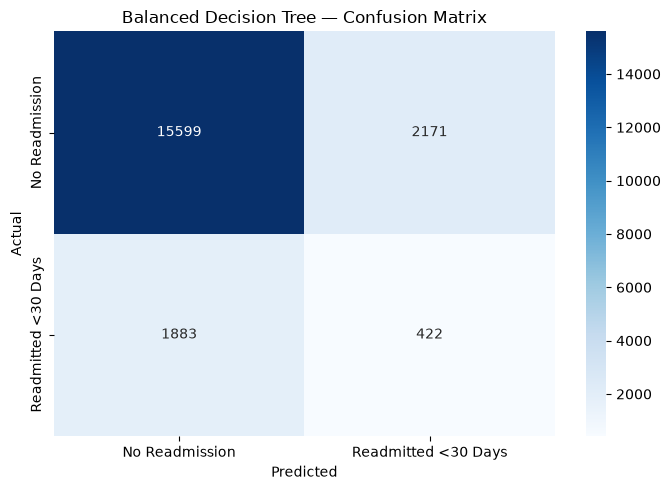

In [104]:
# ============================================================
# BALANCED DECISION TREE
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_balanced_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission", "Readmitted <30 Days"],
    yticklabels=["No Readmission", "Readmitted <30 Days"]
)

plt.title("Balanced Decision Tree — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# CONTROLLED / PRUNED DECISION TREE PIPELINE
# ============================================================

pruned_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        
        (
            "model",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=20,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("=" * 70)
print("CONTROLLED DECISION TREE PIPELINE CREATED")
print("=" * 70)

CONTROLLED DECISION TREE PIPELINE CREATED


In [106]:
# ============================================================
# TRAIN CONTROLLED DECISION TREE
# ============================================================

pruned_tree_pipeline.fit(
    X_train,
    y_train
)

y_pred_pruned_tree = pruned_tree_pipeline.predict(
    X_test
)

y_prob_pruned_tree = pruned_tree_pipeline.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("CONTROLLED DECISION TREE TRAINING COMPLETED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_pruned_tree.shape}")
print(f"Probability shape: {y_prob_pruned_tree.shape}")

CONTROLLED DECISION TREE TRAINING COMPLETED

Prediction shape: (20075,)
Probability shape: (20075,)


In [107]:
# ============================================================
# CONTROLLED DECISION TREE PERFORMANCE
# ============================================================

pruned_tree_accuracy = accuracy_score(
    y_test,
    y_pred_pruned_tree
)

pruned_tree_precision = precision_score(
    y_test,
    y_pred_pruned_tree,
    zero_division=0
)

pruned_tree_recall = recall_score(
    y_test,
    y_pred_pruned_tree,
    zero_division=0
)

pruned_tree_f1 = f1_score(
    y_test,
    y_pred_pruned_tree,
    zero_division=0
)

pruned_tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_pruned_tree
)

pruned_tree_avg_precision = average_precision_score(
    y_test,
    y_prob_pruned_tree
)

print("=" * 70)
print("CONTROLLED DECISION TREE PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:          {pruned_tree_accuracy:.4f}")
print(f"Precision:         {pruned_tree_precision:.4f}")
print(f"Recall:            {pruned_tree_recall:.4f}")
print(f"F1 Score:          {pruned_tree_f1:.4f}")
print(f"ROC-AUC:           {pruned_tree_roc_auc:.4f}")
print(f"Average Precision: {pruned_tree_avg_precision:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_pruned_tree,
        digits=4,
        zero_division=0
    )
)

CONTROLLED DECISION TREE PERFORMANCE

Accuracy:          0.6516
Precision:         0.1707
Recall:            0.5275
F1 Score:          0.2580
ROC-AUC:           0.6247
Average Precision: 0.1893

Classification Report:
              precision    recall  f1-score   support

           0     0.9159    0.6676    0.7723     17770
           1     0.1707    0.5275    0.2580      2305

    accuracy                         0.6516     20075
   macro avg     0.5433    0.5976    0.5152     20075
weighted avg     0.8304    0.6516    0.7133     20075



In [108]:
# ============================================================
# CONTROLLED DECISION TREE CONFUSION MATRIX
# ============================================================

cm_pruned_tree = confusion_matrix(
    y_test,
    y_pred_pruned_tree
)

tn, fp, fn, tp = cm_pruned_tree.ravel()

print("=" * 70)
print("CONTROLLED DECISION TREE CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_pruned_tree)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

CONTROLLED DECISION TREE CONFUSION MATRIX

Confusion Matrix:
[[11864  5906]
 [ 1089  1216]]

Classification Breakdown:
True Negatives:  11,864
False Positives: 5,906
False Negatives: 1,089
True Positives:  1,216


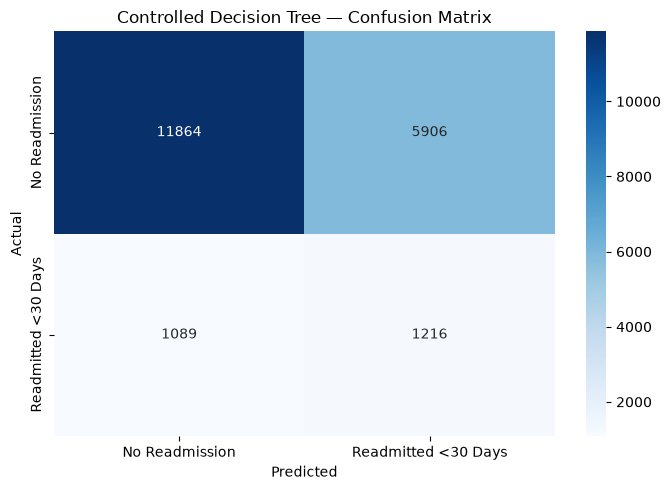

In [109]:
# ============================================================
# CONTROLLED DECISION TREE
# CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_pruned_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission", "Readmitted <30 Days"],
    yticklabels=["No Readmission", "Readmitted <30 Days"]
)

plt.title("Controlled Decision Tree — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [110]:
# ============================================================
# 5-FOLD CROSS-VALIDATION
# CONTROLLED / PRUNED DECISION TREE
# ============================================================

pruned_tree_cv_results = []

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: CONTROLLED / PRUNED DECISION TREE")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_train, y_train, groups=groups_train),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split fold data
    # --------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create fresh pipeline
    # --------------------------------------------------------

    fold_model = clone(pruned_tree_pipeline)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_val_pred = fold_model.predict(
        X_val_fold
    )

    y_val_prob = fold_model.predict_proba(
        X_val_fold
    )[:, 1]

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val_fold,
        y_val_pred
    )

    precision = precision_score(
        y_val_fold,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_fold,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_fold,
        y_val_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val_fold,
        y_val_prob
    )

    avg_precision = average_precision_score(
        y_val_fold,
        y_val_prob
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    pruned_tree_cv_results.append(
        {
            "fold": fold,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": roc_auc,
            "average_precision": avg_precision
        }
    )

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {roc_auc:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: CONTROLLED / PRUNED DECISION TREE

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6364 | Recall: 0.5232 | F1: 0.2705

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6409 | Recall: 0.6087 | F1: 0.2519

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6292 | Recall: 0.5000 | F1: 0.2492

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6387 | Recall: 0.6381 | F1: 0.2473

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6342 | Recall: 0.6122 | F1: 0.2532


In [111]:
# ============================================================
# CONTROLLED DECISION TREE CV RESULTS
# ============================================================

pruned_tree_cv_df = pd.DataFrame(
    pruned_tree_cv_results
)

display(
    pruned_tree_cv_df.round(4)
)

# Exclude fold number from performance summary
metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision"
]

pruned_tree_cv_summary = pd.DataFrame(
    {
        "Mean": pruned_tree_cv_df[metric_columns].mean(),
        "Std": pruned_tree_cv_df[metric_columns].std()
    }
)

pruned_tree_cv_summary["Mean ± Std"] = (
    pruned_tree_cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + pruned_tree_cv_summary["Std"].round(4).astype(str)
)

print("\n" + "=" * 70)
print("CONTROLLED DECISION TREE CV SUMMARY")
print("=" * 70)

display(pruned_tree_cv_summary)

,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.6808,0.1824,0.5232,0.2705,0.6364,0.1939
1,2,0.5908,0.1588,0.6087,0.2519,0.6409,0.2036
2,3,0.6594,0.1660,0.5000,0.2492,0.6292,0.1809
3,4,0.5609,0.1534,0.6381,0.2473,0.6387,0.1923
4,5,0.5917,0.1596,0.6122,0.2532,0.6342,0.1917



CONTROLLED DECISION TREE CV SUMMARY


,Mean,Std,Mean ± Std
accuracy,0.616726,0.050860,0.6167 ± 0.0509
precision,0.164038,0.011174,0.164 ± 0.0112
recall,0.576440,0.060826,0.5764 ± 0.0608
f1_score,0.254432,0.009244,0.2544 ± 0.0092
roc_auc,0.635888,0.004482,0.6359 ± 0.0045
average_precision,0.192471,0.008061,0.1925 ± 0.0081


# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple Decision Trees. Unlike a single Decision Tree, Random Forest can reduce model variance and improve generalization by averaging predictions across many trees.

For this project, the model will be evaluated using the same patient-aware data split and evaluation framework used for the previous models.

The experiment will begin with a baseline Random Forest model, followed by evaluation on the untouched test set and patient-aware 5-fold cross-validation using StratifiedGroupKFold.

Because the target variable is imbalanced, additional class-weighting experiments may be conducted after establishing the baseline performance.

In [112]:
# ============================================================
# BASELINE RANDOM FOREST PIPELINE
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("=" * 70)
print("BASELINE RANDOM FOREST PIPELINE CREATED")
print("=" * 70)

# ============================================================
# BASELINE RANDOM FOREST TRAINING
# ============================================================

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("=" * 70)
print("BASELINE RANDOM FOREST TRAINING COMPLETED")
print("=" * 70)



BASELINE RANDOM FOREST PIPELINE CREATED
BASELINE RANDOM FOREST TRAINING COMPLETED


In [113]:
# ============================================================
# BASELINE RANDOM FOREST PREDICTIONS
# ============================================================

y_pred_rf = random_forest_pipeline.predict(
    X_test
)

y_prob_rf = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("BASELINE RANDOM FOREST PREDICTIONS GENERATED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_rf.shape}")
print(f"Probability shape: {y_prob_rf.shape}")

BASELINE RANDOM FOREST PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


In [114]:
# ============================================================
# BASELINE RANDOM FOREST PERFORMANCE
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

rf_avg_precision = average_precision_score(
    y_test,
    y_prob_rf
)

print("=" * 70)
print("BASELINE RANDOM FOREST PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy:          {rf_accuracy:.4f}")
print(f"Precision:         {rf_precision:.4f}")
print(f"Recall:            {rf_recall:.4f}")
print(f"F1 Score:          {rf_f1:.4f}")
print(f"ROC-AUC:           {rf_roc_auc:.4f}")
print(f"Average Precision: {rf_avg_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4,
        zero_division=0
    )
)

BASELINE RANDOM FOREST PERFORMANCE

Accuracy:          0.8853
Precision:         0.7500
Recall:            0.0013
F1 Score:          0.0026
ROC-AUC:           0.6545
Average Precision: 0.2178

Classification Report:
              precision    recall  f1-score   support

           0     0.8853    0.9999    0.9391     17770
           1     0.7500    0.0013    0.0026      2305

    accuracy                         0.8853     20075
   macro avg     0.8177    0.5006    0.4709     20075
weighted avg     0.8698    0.8853    0.8316     20075



In [115]:
# ============================================================
# BASELINE RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

tn, fp, fn, tp = cm_rf.ravel()

print("=" * 70)
print("BASELINE RANDOM FOREST CONFUSION MATRIX")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_rf)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BASELINE RANDOM FOREST CONFUSION MATRIX

Confusion Matrix:
[[17769     1]
 [ 2302     3]]

Classification Breakdown:
True Negatives:  17,769
False Positives: 1
False Negatives: 2,302
True Positives:  3


In [116]:
# ============================================================
# RANDOM FOREST PREDICTED PROBABILITY ANALYSIS
# ============================================================

print("=" * 70)
print("RANDOM FOREST PREDICTED PROBABILITY ANALYSIS")
print("=" * 70)

print("\nProbability summary:")
print(
    pd.Series(y_prob_rf).describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print("\nHighest predicted probability:")
print(y_prob_rf.max())

print("\nNumber of probabilities >= 0.50:")
print((y_prob_rf >= 0.50).sum())

RANDOM FOREST PREDICTED PROBABILITY ANALYSIS

Probability summary:
count    20075.000000
mean         0.114125
std          0.062876
min          0.000000
1%           0.016667
5%           0.033333
10%          0.046667
25%          0.070000
50%          0.103333
75%          0.146667
90%          0.196667
95%          0.233333
99%          0.313333
max          0.673333
dtype: float64

Highest predicted probability:
0.6733333333333333

Number of probabilities >= 0.50:
4


In [117]:
# ============================================================
# RANDOM FOREST PROBABILITIES BY ACTUAL CLASS
# ============================================================

rf_probability_df = pd.DataFrame({
    "actual_readmission": y_test,
    "predicted_probability": y_prob_rf
})

print("=" * 70)
print("PROBABILITY DISTRIBUTION BY ACTUAL CLASS")
print("=" * 70)

print(
    rf_probability_df
    .groupby("actual_readmission")["predicted_probability"]
    .describe()
)

PROBABILITY DISTRIBUTION BY ACTUAL CLASS
                      count      mean       std       min       25%       50%  \
actual_readmission                                                              
0                   17770.0  0.109592  0.058939  0.000000  0.066667  0.100000   
1                    2305.0  0.149073  0.079207  0.006667  0.093333  0.133333   

                     75%       max  
actual_readmission                  
0                   0.14  0.513333  
1                   0.19  0.673333  


In [118]:
# ============================================================
# RANDOM FOREST THRESHOLD ANALYSIS
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_rf >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "positive_predictions": y_pred_threshold.sum()
    })

rf_threshold_df = pd.DataFrame(
    threshold_results
)

print("=" * 70)
print("RANDOM FOREST THRESHOLD ANALYSIS")
print("=" * 70)

display(
    rf_threshold_df.round(4)
)

RANDOM FOREST THRESHOLD ANALYSIS


,threshold,accuracy,precision,recall,f1_score,positive_predictions
0,0.05,0.2182,0.1229,0.9471,0.2176,17756
1,0.10,0.5119,0.1522,0.7115,0.2508,10774
2,0.15,0.7439,0.2036,0.4226,0.2748,4784
3,0.20,0.8418,0.2744,0.2295,0.2499,1928
4,0.25,0.8748,0.3575,0.1132,0.1720,730
5,0.30,0.8828,0.4158,0.0503,0.0898,279
6,0.35,0.8852,0.5051,0.0217,0.0416,99
7,0.40,0.8854,0.5476,0.0100,0.0196,42
8,0.45,0.8852,0.5000,0.0022,0.0043,10
9,0.50,0.8853,0.7500,0.0013,0.0026,4


## Baseline Random Forest — 5-Fold Patient-Aware Cross-Validation

To evaluate the generalization performance of the baseline Random Forest, 5-fold StratifiedGroupKFold cross-validation is performed on the training dataset.

Patient IDs are used as grouping variables to ensure that records belonging to the same patient never appear in both the training and validation portions of a fold.

For each fold, the model is trained on approximately 80% of the training patients and evaluated on the remaining 20% of unseen patients.

In addition to fold-level performance metrics, out-of-fold predicted probabilities are collected. These probabilities will later be used to explore and select an appropriate classification threshold without using the final test set.

In [119]:
# ============================================================
# RANDOM FOREST — OUT-OF-FOLD STORAGE
# ============================================================

import numpy as np
import pandas as pd

# Stores predicted probabilities for the positive class
oof_prob_rf = np.zeros(len(X_train))

# Stores predicted classes using the default threshold
oof_pred_rf = np.zeros(len(X_train), dtype=int)

# Stores fold-level metrics
rf_cv_results = []

print("=" * 70)
print("RANDOM FOREST CROSS-VALIDATION STORAGE CREATED")
print("=" * 70)

print(f"\nTraining rows: {len(X_train):,}")
print(f"OOF probability array shape: {oof_prob_rf.shape}")
print(f"OOF prediction array shape: {oof_pred_rf.shape}")

RANDOM FOREST CROSS-VALIDATION STORAGE CREATED

Training rows: 80,039
OOF probability array shape: (80039,)
OOF prediction array shape: (80039,)


In [120]:
# ============================================================
# 5-FOLD STRATIFIED GROUP CROSS-VALIDATION
# BASELINE RANDOM FOREST
# ============================================================

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BASELINE RANDOM FOREST")
print("=" * 70)

patient_train_cv = df_patient_nbr.loc[
    X_train.index,
    "patient_nbr"
]

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(
        X_train,
        y_train,
        groups=patient_train_cv
    ),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create a fresh Random Forest pipeline
    # --------------------------------------------------------

    rf_cv_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    # --------------------------------------------------------
    # Train on fold training data
    # --------------------------------------------------------

    rf_cv_pipeline.fit(
        X_fold_train,
        y_fold_train
    )

    # --------------------------------------------------------
    # Generate validation predictions
    # --------------------------------------------------------

    y_fold_pred = rf_cv_pipeline.predict(
        X_fold_val
    )

    y_fold_prob = rf_cv_pipeline.predict_proba(
        X_fold_val
    )[:, 1]

    # --------------------------------------------------------
    # Store out-of-fold predictions
    # --------------------------------------------------------

    oof_pred_rf[val_idx] = y_fold_pred

    oof_prob_rf[val_idx] = y_fold_prob

    # --------------------------------------------------------
    # Calculate fold metrics
    # --------------------------------------------------------

    fold_result = {
        "fold": fold,

        "accuracy": accuracy_score(
            y_fold_val,
            y_fold_pred
        ),

        "precision": precision_score(
            y_fold_val,
            y_fold_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_fold_val,
            y_fold_pred,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_fold_val,
            y_fold_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_fold_val,
            y_fold_prob
        ),

        "average_precision": average_precision_score(
            y_fold_val,
            y_fold_prob
        )
    }

    rf_cv_results.append(
        fold_result
    )

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_result['roc_auc']:.4f} | "
        f"Recall: {fold_result['recall']:.4f} | "
        f"F1: {fold_result['f1_score']:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: BASELINE RANDOM FOREST

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6529 | Recall: 0.0006 | F1: 0.0011

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6644 | Recall: 0.0000 | F1: 0.0000

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6459 | Recall: 0.0006 | F1: 0.0011

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6598 | Recall: 0.0033 | F1: 0.0066

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6444 | Recall: 0.0006 | F1: 0.0011


In [121]:
rf_cv_results_df = pd.DataFrame(rf_cv_results)

rf_cv_summary = pd.DataFrame({
    "Mean": rf_cv_results_df.mean(numeric_only=True),
    "Std": rf_cv_results_df.std(numeric_only=True)
})

rf_cv_summary["Mean ± Std"] = (
    rf_cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + rf_cv_summary["Std"].round(4).astype(str)
)

rf_cv_summary = rf_cv_summary.drop(
    index="fold",
    errors="ignore"
)

display(rf_cv_results_df.round(4))
display(rf_cv_summary)

,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.8870,1.0,0.0006,0.0011,0.6529,0.2191
1,2,0.8868,0.0,0.0000,0.0000,0.6644,0.2201
2,3,0.8870,1.0,0.0006,0.0011,0.6459,0.2027
3,4,0.8869,0.5,0.0033,0.0066,0.6598,0.2269
4,5,0.8870,1.0,0.0006,0.0011,0.6444,0.2058


,Mean,Std,Mean ± Std
accuracy,0.886930,0.000093,0.8869 ± 0.0001
precision,0.700000,0.447214,0.7 ± 0.4472
recall,0.000994,0.001319,0.001 ± 0.0013
f1_score,0.001980,0.002619,0.002 ± 0.0026
roc_auc,0.653490,0.008631,0.6535 ± 0.0086
average_precision,0.214922,0.010241,0.2149 ± 0.0102


In [122]:
# ============================================================
# RANDOM FOREST — OOF THRESHOLD ANALYSIS
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

rf_oof_threshold_results = []

for threshold in thresholds:

    y_oof_pred_threshold = (
        oof_prob_rf >= threshold
    ).astype(int)

    rf_oof_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_train,
            y_oof_pred_threshold
        ),
        "precision": precision_score(
            y_train,
            y_oof_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            y_oof_pred_threshold,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_train,
            y_oof_pred_threshold,
            zero_division=0
        ),
        "positive_predictions": y_oof_pred_threshold.sum()
    })

rf_oof_threshold_df = pd.DataFrame(
    rf_oof_threshold_results
)

print("=" * 70)
print("RANDOM FOREST — OOF THRESHOLD ANALYSIS")
print("=" * 70)

display(
    rf_oof_threshold_df.round(4)
)

RANDOM FOREST — OOF THRESHOLD ANALYSIS


,threshold,accuracy,precision,recall,f1_score,positive_predictions
0,0.05,0.2165,0.1218,0.9544,0.2160,70937
1,0.10,0.5140,0.1501,0.7070,0.2476,42645
2,0.15,0.7407,0.1990,0.4273,0.2715,19437
3,0.20,0.8412,0.2647,0.2272,0.2446,7770
4,0.25,0.8751,0.3487,0.1200,0.1785,3114
5,0.30,0.8843,0.4135,0.0555,0.0978,1214
6,0.35,0.8867,0.4845,0.0242,0.0461,452
7,0.40,0.8871,0.5407,0.0103,0.0202,172
8,0.45,0.8870,0.5323,0.0036,0.0072,62
9,0.50,0.8869,0.5556,0.0011,0.0022,18


In [123]:
# ============================================================
# FINAL RANDOM FOREST TEST PREDICTION
# USING OOF-SELECTED THRESHOLD
# ============================================================

rf_final_threshold = 0.15

y_pred_rf_threshold = (
    y_prob_rf >= rf_final_threshold
).astype(int)

print("=" * 70)
print("FINAL RANDOM FOREST PREDICTIONS")
print("=" * 70)

print(f"\nSelected threshold: {rf_final_threshold}")
print(
    f"Positive predictions: "
    f"{y_pred_rf_threshold.sum():,}"
)

# ============================================================
# FINAL RANDOM FOREST TEST PERFORMANCE
# ============================================================

print("=" * 70)
print("FINAL RANDOM FOREST PERFORMANCE")
print("THRESHOLD SELECTED FROM OOF CROSS-VALIDATION")
print("=" * 70)

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf_threshold):.4f}")
print(
    f"Precision: {precision_score(y_test, y_pred_rf_threshold, zero_division=0):.4f}"
)
print(
    f"Recall:    {recall_score(y_test, y_pred_rf_threshold, zero_division=0):.4f}"
)
print(
    f"F1 Score:  {f1_score(y_test, y_pred_rf_threshold, zero_division=0):.4f}"
)
print(
    f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}"
)
print(
    f"Average Precision: "
    f"{average_precision_score(y_test, y_prob_rf):.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_threshold,
        zero_division=0
    )
)

FINAL RANDOM FOREST PREDICTIONS

Selected threshold: 0.15
Positive predictions: 4,784
FINAL RANDOM FOREST PERFORMANCE
THRESHOLD SELECTED FROM OOF CROSS-VALIDATION

Accuracy:  0.7439
Precision: 0.2036
Recall:    0.4226
F1 Score:  0.2748
ROC-AUC:   0.6545
Average Precision: 0.2178

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.84     17770
           1       0.20      0.42      0.27      2305

    accuracy                           0.74     20075
   macro avg       0.56      0.60      0.56     20075
weighted avg       0.83      0.74      0.78     20075



FINAL RANDOM FOREST CONFUSION MATRIX
THRESHOLD = 0.15

Confusion Matrix:
[[13960  3810]
 [ 1331   974]]

Classification Breakdown:
True Negatives:  13,960
False Positives: 3,810
False Negatives: 1,331
True Positives:  974


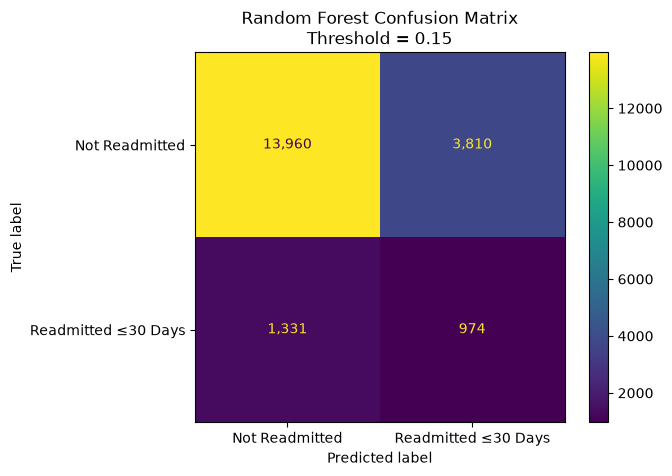

In [124]:
y_pred_rf_threshold = (y_prob_rf >= rf_final_threshold).astype(int)
# ============================================================
# FINAL RANDOM FOREST CONFUSION MATRIX
# THRESHOLD = 0.15
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf_final = confusion_matrix(
    y_test,
    y_pred_rf_threshold
)

print("=" * 70)
print("FINAL RANDOM FOREST CONFUSION MATRIX")
print(f"THRESHOLD = {rf_final_threshold}")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_rf_final)

tn, fp, fn, tp = cm_rf_final.ravel()

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_final,
    display_labels=["Not Readmitted", "Readmitted ≤30 Days"]
)

disp.plot(
    values_format=","
)

plt.title(
    f"Random Forest Confusion Matrix\nThreshold = {rf_final_threshold}"
)

plt.show()

RANDOM FOREST ROC-AUC

ROC-AUC Score: 0.6545


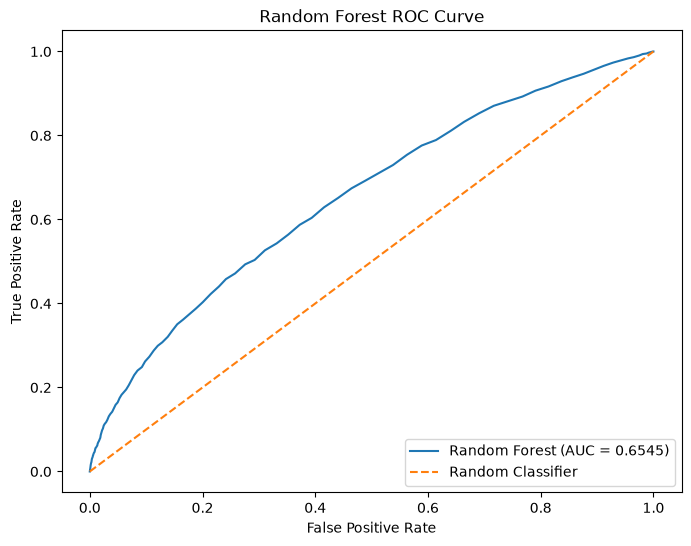

In [125]:
# ============================================================
# RANDOM FOREST ROC-AUC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

print("=" * 70)
print("RANDOM FOREST ROC-AUC")
print("=" * 70)

print(f"\nROC-AUC Score: {roc_auc_rf:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")

plt.show()

In [126]:
# ============================================================
# BALANCED RANDOM FOREST PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

balanced_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("=" * 70)
print("BALANCED RANDOM FOREST PIPELINE CREATED")
print("=" * 70)

BALANCED RANDOM FOREST PIPELINE CREATED


In [127]:
# ============================================================
# BALANCED RANDOM FOREST TRAINING
# ============================================================

balanced_rf_pipeline.fit(
    X_train,
    y_train
)

print("=" * 70)
print("BALANCED RANDOM FOREST TRAINING COMPLETED")
print("=" * 70)

BALANCED RANDOM FOREST TRAINING COMPLETED


In [128]:
# ============================================================
# BALANCED RANDOM FOREST PREDICTIONS
# ============================================================

y_pred_balanced_rf = balanced_rf_pipeline.predict(
    X_test
)

y_prob_balanced_rf = balanced_rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("=" * 70)
print("BALANCED RANDOM FOREST PREDICTIONS GENERATED")
print("=" * 70)

print(f"\nPrediction shape: {y_pred_balanced_rf.shape}")
print(f"Probability shape: {y_prob_balanced_rf.shape}")

BALANCED RANDOM FOREST PREDICTIONS GENERATED

Prediction shape: (20075,)
Probability shape: (20075,)


In [129]:
# ============================================================
# BALANCED RANDOM FOREST PERFORMANCE
# DEFAULT THRESHOLD = 0.50
# ============================================================

print("=" * 70)
print("BALANCED RANDOM FOREST PERFORMANCE")
print("=" * 70)

print(
    f"\nAccuracy:          "
    f"{accuracy_score(y_test, y_pred_balanced_rf):.4f}"
)

print(
    f"Precision:         "
    f"{precision_score(y_test, y_pred_balanced_rf, zero_division=0):.4f}"
)

print(
    f"Recall:            "
    f"{recall_score(y_test, y_pred_balanced_rf, zero_division=0):.4f}"
)

print(
    f"F1 Score:          "
    f"{f1_score(y_test, y_pred_balanced_rf, zero_division=0):.4f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_score(y_test, y_prob_balanced_rf):.4f}"
)

print(
    f"Average Precision: "
    f"{average_precision_score(y_test, y_prob_balanced_rf):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_balanced_rf,
        zero_division=0
    )
)

BALANCED RANDOM FOREST PERFORMANCE

Accuracy:          0.8837
Precision:         0.4085
Recall:            0.0291
F1 Score:          0.0543
ROC-AUC:           0.6613
Average Precision: 0.2156

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     17770
           1       0.41      0.03      0.05      2305

    accuracy                           0.88     20075
   macro avg       0.65      0.51      0.50     20075
weighted avg       0.83      0.88      0.84     20075



BALANCED RANDOM FOREST CONFUSION MATRIX
DEFAULT THRESHOLD = 0.50

Confusion Matrix:
[[17673    97]
 [ 2238    67]]

Classification Breakdown:
True Negatives:  17,673
False Positives: 97
False Negatives: 2,238
True Positives:  67


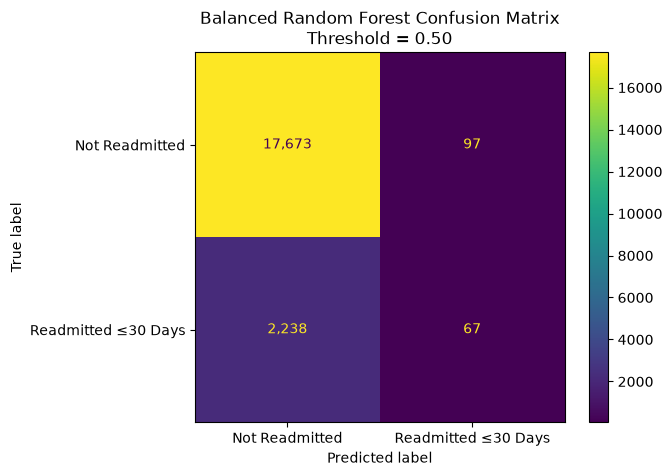

In [130]:
# ============================================================
# BALANCED RANDOM FOREST CONFUSION MATRIX
# DEFAULT THRESHOLD = 0.50
# ============================================================

cm_balanced_rf = confusion_matrix(
    y_test,
    y_pred_balanced_rf
)

tn, fp, fn, tp = cm_balanced_rf.ravel()

print("=" * 70)
print("BALANCED RANDOM FOREST CONFUSION MATRIX")
print("DEFAULT THRESHOLD = 0.50")
print("=" * 70)

print("\nConfusion Matrix:")
print(cm_balanced_rf)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced_rf,
    display_labels=[
        "Not Readmitted",
        "Readmitted ≤30 Days"
    ]
)

disp.plot(values_format=",")

plt.title(
    "Balanced Random Forest Confusion Matrix\nThreshold = 0.50"
)

plt.show()

In [131]:
# ============================================================
# BALANCED RANDOM FOREST — OOF STORAGE
# ============================================================

import numpy as np
import pandas as pd

oof_prob_balanced_rf = np.zeros(len(X_train))

balanced_rf_cv_results = []

print("=" * 70)
print("BALANCED RANDOM FOREST OOF STORAGE CREATED")
print("=" * 70)

BALANCED RANDOM FOREST OOF STORAGE CREATED


In [132]:
# ============================================================
# 5-FOLD CROSS-VALIDATION
# MODEL: BALANCED RANDOM FOREST
# ============================================================

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BALANCED RANDOM FOREST")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(
        X_train,
        y_train,
        groups=patient_train_cv
    ),
    start=1
):

    print(f"\nTraining Fold {fold}...")

    # --------------------------------------------------------
    # Split current training fold
    # --------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create a fresh model for each fold
    # --------------------------------------------------------

    balanced_rf_cv_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),

            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=1
                )
            )
        ]
    )

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    balanced_rf_cv_pipeline.fit(
        X_train_fold,
        y_train_fold
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_val_pred = balanced_rf_cv_pipeline.predict(
        X_val_fold
    )

    y_val_prob = balanced_rf_cv_pipeline.predict_proba(
        X_val_fold
    )[:, 1]

    # Store OOF probabilities
    oof_prob_balanced_rf[val_idx] = y_val_prob

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    fold_result = {
        "fold": fold,

        "accuracy": accuracy_score(
            y_val_fold,
            y_val_pred
        ),

        "precision": precision_score(
            y_val_fold,
            y_val_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_val_fold,
            y_val_pred,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_val_fold,
            y_val_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_val_fold,
            y_val_prob
        ),

        "average_precision": average_precision_score(
            y_val_fold,
            y_val_prob
        )
    }

    balanced_rf_cv_results.append(
        fold_result
    )

    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_result['roc_auc']:.4f} | "
        f"Recall: {fold_result['recall']:.4f} | "
        f"F1: {fold_result['f1_score']:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: BALANCED RANDOM FOREST

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6609 | Recall: 0.0282 | F1: 0.0534

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6711 | Recall: 0.0243 | F1: 0.0461

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6582 | Recall: 0.0265 | F1: 0.0492

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6739 | Recall: 0.0387 | F1: 0.0717

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6608 | Recall: 0.0243 | F1: 0.0457


In [133]:
# ============================================================
# BALANCED RANDOM FOREST — CV RESULTS SUMMARY
# ============================================================

balanced_rf_cv_results_df = pd.DataFrame(
    balanced_rf_cv_results
)

balanced_rf_cv_summary = pd.DataFrame({
    "Mean": balanced_rf_cv_results_df.mean(numeric_only=True),
    "Std": balanced_rf_cv_results_df.std(numeric_only=True)
})

balanced_rf_cv_summary["Mean ± Std"] = (
    balanced_rf_cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + balanced_rf_cv_summary["Std"].round(4).astype(str)
)

balanced_rf_cv_summary = balanced_rf_cv_summary.drop(
    index="fold",
    errors="ignore"
)

print("=" * 70)
print("BALANCED RANDOM FOREST — 5-FOLD CV SUMMARY")
print("=" * 70)

display(balanced_rf_cv_results_df.round(4))
display(balanced_rf_cv_summary)

BALANCED RANDOM FOREST — 5-FOLD CV SUMMARY


,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.8871,0.5152,0.0282,0.0534,0.6609,0.2204
1,2,0.8863,0.4583,0.0243,0.0461,0.6711,0.2201
2,3,0.8842,0.3429,0.0265,0.0492,0.6582,0.2012
3,4,0.8867,0.4895,0.0387,0.0717,0.6739,0.2233
4,5,0.8853,0.3860,0.0243,0.0457,0.6608,0.2048


,Mean,Std,Mean ± Std
accuracy,0.885931,0.001187,0.8859 ± 0.0012
precision,0.438363,0.072073,0.4384 ± 0.0721
recall,0.028392,0.005976,0.0284 ± 0.006
f1_score,0.053241,0.010762,0.0532 ± 0.0108
roc_auc,0.665002,0.007028,0.665 ± 0.007
average_precision,0.213952,0.010161,0.214 ± 0.0102


In [134]:
# ============================================================
# BALANCED RANDOM FOREST — OOF THRESHOLD ANALYSIS
# ============================================================

thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results_balanced_rf = []

for threshold in thresholds:

    # Convert probabilities into predictions
    y_oof_pred = (
        oof_prob_balanced_rf >= threshold
    ).astype(int)

    # Calculate metrics
    threshold_results_balanced_rf.append({
        "threshold": threshold,

        "accuracy": accuracy_score(
            y_train,
            y_oof_pred
        ),

        "precision": precision_score(
            y_train,
            y_oof_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_train,
            y_oof_pred,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_train,
            y_oof_pred,
            zero_division=0
        ),

        "positive_predictions": y_oof_pred.sum()
    })


threshold_results_balanced_rf_df = pd.DataFrame(
    threshold_results_balanced_rf
)

print("=" * 70)
print("BALANCED RANDOM FOREST — OOF THRESHOLD ANALYSIS")
print("=" * 70)

display(
    threshold_results_balanced_rf_df.round(4)
)

BALANCED RANDOM FOREST — OOF THRESHOLD ANALYSIS


,threshold,accuracy,precision,recall,f1_score,positive_predictions
0,0.05,0.1222,0.1140,0.9982,0.2046,79281
1,0.06,0.1314,0.1148,0.9952,0.2058,78485
2,0.07,0.1383,0.1154,0.9929,0.2068,77892
3,0.08,0.1570,0.1169,0.9852,0.2091,76258
4,0.09,0.1764,0.1186,0.9769,0.2115,74551
5,0.10,0.1904,0.1197,0.9693,0.2131,73297
6,0.11,0.2230,0.1225,0.9523,0.2171,70375
7,0.12,0.2522,0.1252,0.9378,0.2210,67777
8,0.13,0.2731,0.1272,0.9260,0.2237,65893
9,0.14,0.3050,0.1301,0.9048,0.2275,62954


In [135]:
# ============================================================
# BALANCED RANDOM FOREST
# FINAL TEST EVALUATION USING OOF-SELECTED THRESHOLD
# ============================================================

selected_threshold_balanced_rf = 0.26

# Convert test probabilities to predictions
y_pred_balanced_rf_threshold = (
    y_prob_balanced_rf >= selected_threshold_balanced_rf
).astype(int)


# Calculate metrics
threshold_accuracy_balanced_rf = accuracy_score(
    y_test,
    y_pred_balanced_rf_threshold
)

threshold_precision_balanced_rf = precision_score(
    y_test,
    y_pred_balanced_rf_threshold,
    zero_division=0
)

threshold_recall_balanced_rf = recall_score(
    y_test,
    y_pred_balanced_rf_threshold,
    zero_division=0
)

threshold_f1_balanced_rf = f1_score(
    y_test,
    y_pred_balanced_rf_threshold,
    zero_division=0
)


print("=" * 70)
print(
    "BALANCED RANDOM FOREST — FINAL TEST PERFORMANCE"
)
print(
    f"THRESHOLD = {selected_threshold_balanced_rf}"
)
print("=" * 70)

print(
    f"\nAccuracy:  {threshold_accuracy_balanced_rf:.4f}"
)

print(
    f"Precision: {threshold_precision_balanced_rf:.4f}"
)

print(
    f"Recall:    {threshold_recall_balanced_rf:.4f}"
)

print(
    f"F1 Score:  {threshold_f1_balanced_rf:.4f}"
)

BALANCED RANDOM FOREST — FINAL TEST PERFORMANCE
THRESHOLD = 0.26

Accuracy:  0.6994
Precision: 0.1901
Recall:    0.4963
F1 Score:  0.2749


# XGBoost Classifier

## Model Overview

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that builds decision trees sequentially. Unlike Random Forest, where trees are built independently, XGBoost builds each new tree to improve the errors made by the previous trees.

The model is particularly useful because it can capture complex and non-linear relationships between features while using gradient boosting to progressively improve predictions.

For this project, XGBoost is being evaluated as a potential model for predicting whether a patient will experience hospital readmission.

---

## Baseline XGBoost

The first XGBoost model is created as a baseline model without applying explicit class imbalance handling or hyperparameter tuning.

The baseline model uses:

- `objective="binary:logistic"` to perform binary classification and generate predicted probabilities.
- `eval_metric="logloss"` as the training evaluation metric.
- `random_state=42` to ensure reproducible results.
- `n_jobs=-1` to use all available CPU cores during training.

The same preprocessing pipeline used by the previous machine learning models is applied before the data is passed to the XGBoost classifier.

At this stage, no explicit class weighting is applied. This allows us to establish a baseline performance before introducing imbalance-handling techniques such as `scale_pos_weight`.

---

## Evaluation Strategy

The baseline XGBoost model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Average Precision
- Classification Report
- Confusion Matrix

Because the dataset contains an imbalanced target variable, accuracy alone will not be used to determine model quality. Particular attention will be given to recall, F1 Score, ROC-AUC, and Average Precision for the minority readmission class.

The initial evaluation will use the default classification threshold of `0.50`.

After evaluating the baseline model, further experiments will be performed to examine the impact of class imbalance handling, cross-validation, and probability threshold optimization.

In [136]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

print("=" * 70)
print("CREATING BASELINE XGBOOST PIPELINE")
print("=" * 70)

baseline_xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

baseline_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_xgb_model)
    ]
)

print("\nBaseline XGBoost pipeline created successfully.")

print("=" * 70)
print("BASELINE XGBOOST TRAINING STARTED")
print("=" * 70)

baseline_xgb_pipeline.fit(
    X_train,
    y_train
)

print("\n" + "=" * 70)
print("BASELINE XGBOOST TRAINING COMPLETED")
print("=" * 70)

CREATING BASELINE XGBOOST PIPELINE

Baseline XGBoost pipeline created successfully.
BASELINE XGBOOST TRAINING STARTED

BASELINE XGBOOST TRAINING COMPLETED


In [137]:
print("=" * 70)
print("BASELINE XGBOOST PREDICTIONS")
print("=" * 70)

# Predicted classes using default threshold = 0.50
y_pred_baseline_xgb = baseline_xgb_pipeline.predict(
    X_test
)

# Predicted probabilities for the positive/readmission class
y_prob_baseline_xgb = baseline_xgb_pipeline.predict_proba(
    X_test
)[:, 1]

print("\nPredictions generated successfully.")

print(f"\nPrediction shape: {y_pred_baseline_xgb.shape}")
print(f"Probability shape: {y_prob_baseline_xgb.shape}")

BASELINE XGBOOST PREDICTIONS

Predictions generated successfully.

Prediction shape: (20075,)
Probability shape: (20075,)


In [138]:
print("=" * 70)
print("XGBOOST PREDICTION LENGTH DIAGNOSTIC")
print("=" * 70)

print(f"X_test length:                {len(X_test)}")
print(f"y_test length:                {len(y_test)}")
print(f"Predicted class length:       {len(y_pred_baseline_xgb)}")
print(f"Predicted probability length: {len(y_prob_baseline_xgb)}")

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values in probabilities:")
print(pd.isna(y_prob_baseline_xgb).sum())

print("\nProbability array shape:")
print(y_prob_baseline_xgb.shape)

XGBOOST PREDICTION LENGTH DIAGNOSTIC
X_test length:                20075
y_test length:                20075
Predicted class length:       20075
Predicted probability length: 20075

X_test shape: (20075, 39)
y_test shape: (20075,)

Missing values in probabilities:
0

Probability array shape:
(20075,)


In [139]:
print("=" * 70)
print("REGENERATING BASELINE XGBOOST PREDICTIONS")
print("=" * 70)

# Generate predicted classes
y_pred_baseline_xgb = baseline_xgb_pipeline.predict(X_test)

# Generate complete probability matrix
y_prob_matrix_baseline_xgb = baseline_xgb_pipeline.predict_proba(X_test)

# Extract positive class probabilities
y_prob_baseline_xgb = y_prob_matrix_baseline_xgb[:, 1]

print("\n" + "=" * 70)
print("PREDICTION VERIFICATION")
print("=" * 70)

print(f"X_test length:                    {len(X_test)}")
print(f"y_test length:                    {len(y_test)}")
print(f"Predicted class length:           {len(y_pred_baseline_xgb)}")
print(f"Probability matrix shape:         {y_prob_matrix_baseline_xgb.shape}")
print(f"Positive probability length:      {len(y_prob_baseline_xgb)}")

assert len(y_test) == len(y_pred_baseline_xgb)
assert len(y_test) == len(y_prob_baseline_xgb)

print("\nAll prediction lengths are correct.")

REGENERATING BASELINE XGBOOST PREDICTIONS

PREDICTION VERIFICATION
X_test length:                    20075
y_test length:                    20075
Predicted class length:           20075
Probability matrix shape:         (20075, 2)
Positive probability length:      20075

All prediction lengths are correct.


In [140]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("=" * 70)
print("BASELINE XGBOOST PERFORMANCE")
print("=" * 70)

accuracy = accuracy_score(
    y_test,
    y_pred_baseline_xgb
)

precision = precision_score(
    y_test,
    y_pred_baseline_xgb,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_baseline_xgb,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_baseline_xgb,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_baseline_xgb
)

avg_precision = average_precision_score(
    y_test,
    y_prob_baseline_xgb
)

print(f"""
Accuracy:          {accuracy:.4f}
Precision:         {precision:.4f}
Recall:            {recall:.4f}
F1 Score:          {f1:.4f}
ROC-AUC:           {roc_auc:.4f}
Average Precision: {avg_precision:.4f}
""")

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_baseline_xgb,
        zero_division=0
    )
)

BASELINE XGBOOST PERFORMANCE

Accuracy:          0.8852
Precision:         0.5000
Recall:            0.0247
F1 Score:          0.0471
ROC-AUC:           0.6588
Average Precision: 0.2171

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17770
           1       0.50      0.02      0.05      2305

    accuracy                           0.89     20075
   macro avg       0.69      0.51      0.49     20075
weighted avg       0.84      0.89      0.84     20075



In [141]:
from sklearn.metrics import confusion_matrix

print("=" * 70)
print("BASELINE XGBOOST CONFUSION MATRIX")
print("DEFAULT THRESHOLD = 0.50")
print("=" * 70)

cm_baseline_xgb = confusion_matrix(
    y_test,
    y_pred_baseline_xgb
)

print("\nConfusion Matrix:")
print(cm_baseline_xgb)

tn, fp, fn, tp = cm_baseline_xgb.ravel()

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BASELINE XGBOOST CONFUSION MATRIX
DEFAULT THRESHOLD = 0.50

Confusion Matrix:
[[17713    57]
 [ 2248    57]]

Classification Breakdown:
True Negatives:  17,713
False Positives: 57
False Negatives: 2,248
True Positives:  57


In [142]:
print("=" * 70)
print("XGBOOST PREDICTED PROBABILITY ANALYSIS")
print("=" * 70)

# Probability distribution by actual class
probability_comparison_xgb = pd.DataFrame({
    "actual_readmission": y_test,
    "predicted_probability": y_prob_baseline_xgb
})

print("\nProbability Distribution by Actual Class:")
print(
    probability_comparison_xgb
    .groupby("actual_readmission")["predicted_probability"]
    .describe()
)

print("\n" + "=" * 70)
print("OVERALL PROBABILITY SUMMARY")
print("=" * 70)

print(
    pd.Series(y_prob_baseline_xgb)
    .describe(
        percentiles=[
            0.01, 0.05, 0.10, 0.25,
            0.50, 0.75, 0.90, 0.95,
            0.99
        ]
    )
)

print(f"\nHighest predicted probability:")
print(y_prob_baseline_xgb.max())

print(f"\nNumber of probabilities >= 0.50:")
print((y_prob_baseline_xgb >= 0.50).sum())

XGBOOST PREDICTED PROBABILITY ANALYSIS

Probability Distribution by Actual Class:
                      count      mean       std       min       25%      50%  \
actual_readmission                                                             
0                   17770.0  0.104504  0.074604  0.001241  0.056157  0.08617   
1                    2305.0  0.156883  0.116061  0.001915  0.079120  0.12413   

                         75%       max  
actual_readmission                      
0                   0.129468  0.855782  
1                   0.196063  0.795301  

OVERALL PROBABILITY SUMMARY
count    20075.000000
mean         0.110518
std          0.082168
min          0.001241
1%           0.015874
5%           0.029888
10%          0.038841
25%          0.057909
50%          0.089496
75%          0.136193
90%          0.204128
95%          0.265118
99%          0.428962
max          0.855782
dtype: float64

Highest predicted probability:
0.85578233

Number of probabilities >= 0.50:
114


In [143]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("BASELINE XGBOOST THRESHOLD ANALYSIS")
print("=" * 70)

threshold_results_xgb = []

# Test thresholds from 0.05 to 0.50
thresholds = np.arange(0.05, 0.51, 0.01)

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_baseline_xgb >= threshold
    ).astype(int)

    threshold_results_xgb.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "positive_predictions": y_pred_threshold.sum()
    })

threshold_results_xgb_df = pd.DataFrame(
    threshold_results_xgb
)

threshold_results_xgb_df

BASELINE XGBOOST THRESHOLD ANALYSIS


,threshold,accuracy,precision,recall,f1_score,positive_predictions
0,0.05,0.280249,0.128078,0.907158,0.224465,16326
1,0.06,0.348095,0.134062,0.856833,0.231848,14732
2,0.07,0.418232,0.141393,0.801735,0.240390,13070
3,0.08,0.483686,0.149443,0.745336,0.248967,11496
4,0.09,0.546152,0.158813,0.687202,0.258001,9974
5,0.10,0.603039,0.170084,0.633406,0.268161,8584
6,0.11,0.650212,0.180982,0.580477,0.275933,7393
7,0.12,0.687522,0.188442,0.520607,0.276721,6368
8,0.13,0.719751,0.197706,0.471150,0.278533,5493
9,0.14,0.747646,0.208817,0.429501,0.281011,4741


In [144]:
best_xgb_f1 = threshold_results_xgb_df.loc[
    threshold_results_xgb_df["f1_score"].idxmax()
]

print("=" * 70)
print("BEST BASELINE XGBOOST THRESHOLD")
print("=" * 70)

print(
    f"\nThreshold: {best_xgb_f1['threshold']:.2f}"
)

print(
    f"Accuracy:  {best_xgb_f1['accuracy']:.4f}"
)

print(
    f"Precision: {best_xgb_f1['precision']:.4f}"
)

print(
    f"Recall:    {best_xgb_f1['recall']:.4f}"
)

print(
    f"F1 Score:  {best_xgb_f1['f1_score']:.4f}"
)

print(
    f"Positive Predictions: "
    f"{int(best_xgb_f1['positive_predictions']):,}"
)

BEST BASELINE XGBOOST THRESHOLD

Threshold: 0.15
Accuracy:  0.7715
Precision: 0.2224
Recall:    0.3965
F1 Score:  0.2850
Positive Predictions: 4,110


In [145]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import pandas as pd

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BASELINE XGBOOST")
print("=" * 70)


# ============================================================
# CREATE CROSS-VALIDATION OBJECT
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# STORE RESULTS
# ============================================================

baseline_xgb_cv_results = []


# ============================================================
# CROSS-VALIDATION LOOP
# ============================================================
patient_train_cv_xgb = df_patient_nbr.loc[
    X_train.index,
    "patient_nbr"
]

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(
        X_train,
        y_train,
        groups=patient_train_cv_xgb
    ),
    start=1
):

    print(f"\nTraining Fold {fold}...")


    # ========================================================
    # SPLIT DATA
    # ========================================================

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]


    # ========================================================
    # GET A FRESH MODEL FOR EACH FOLD
    # ========================================================

    from sklearn.base import clone

    fold_xgb_model = clone(
        baseline_xgb_pipeline
    )


    # ========================================================
    # TRAIN MODEL
    # ========================================================

    fold_xgb_model.fit(
        X_fold_train,
        y_fold_train
    )


    # ========================================================
    # GENERATE PREDICTIONS
    # ========================================================

    y_pred_fold = fold_xgb_model.predict(
        X_fold_val
    )

    y_prob_fold = fold_xgb_model.predict_proba(
        X_fold_val
    )[:, 1]


    # ========================================================
    # CALCULATE METRICS
    # ========================================================

    fold_accuracy = accuracy_score(
        y_fold_val,
        y_pred_fold
    )

    fold_precision = precision_score(
        y_fold_val,
        y_pred_fold,
        zero_division=0
    )

    fold_recall = recall_score(
        y_fold_val,
        y_pred_fold,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_fold_val,
        y_pred_fold,
        zero_division=0
    )

    fold_roc_auc = roc_auc_score(
        y_fold_val,
        y_prob_fold
    )

    fold_average_precision = average_precision_score(
        y_fold_val,
        y_prob_fold
    )


    # ========================================================
    # STORE FOLD RESULTS
    # ========================================================

    baseline_xgb_cv_results.append({

        "fold": fold,

        "accuracy": fold_accuracy,

        "precision": fold_precision,

        "recall": fold_recall,

        "f1_score": fold_f1,

        "roc_auc": fold_roc_auc,

        "average_precision": fold_average_precision
    })


    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_roc_auc:.4f} | "
        f"Recall: {fold_recall:.4f} | "
        f"F1: {fold_f1:.4f}"
    )

5-FOLD CROSS-VALIDATION
MODEL: BASELINE XGBOOST

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6636 | Recall: 0.0337 | F1: 0.0632

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6680 | Recall: 0.0315 | F1: 0.0585

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6614 | Recall: 0.0238 | F1: 0.0451

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6669 | Recall: 0.0409 | F1: 0.0748

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6596 | Recall: 0.0287 | F1: 0.0539


In [146]:
baseline_xgb_cv_results_df = pd.DataFrame(
    baseline_xgb_cv_results
)

baseline_xgb_cv_results_df

,fold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,1,0.887105,0.512605,0.033702,0.063245,0.663606,0.220166
1,2,0.885398,0.416058,0.031457,0.058492,0.667963,0.225370
2,3,0.886244,0.443299,0.023757,0.045097,0.661443,0.210887
3,4,0.885668,0.440476,0.040884,0.074823,0.666945,0.224135
4,5,0.885925,0.433333,0.028729,0.053886,0.659579,0.206680


In [147]:
baseline_xgb_cv_summary = pd.DataFrame({
    
    "Mean": baseline_xgb_cv_results_df[
        [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "average_precision"
        ]
    ].mean(),

    "Std": baseline_xgb_cv_results_df[
        [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "average_precision"
        ]
    ].std()
})

baseline_xgb_cv_summary[
    "Mean ± Std"
] = (
    baseline_xgb_cv_summary["Mean"].round(4).astype(str)
    + " ± "
    + baseline_xgb_cv_summary["Std"].round(4).astype(str)
)

baseline_xgb_cv_summary

,Mean,Std,Mean ± Std
accuracy,0.886068,0.000659,0.8861 ± 0.0007
precision,0.449154,0.037018,0.4492 ± 0.037
recall,0.031706,0.006331,0.0317 ± 0.0063
f1_score,0.059109,0.011046,0.0591 ± 0.011
roc_auc,0.663907,0.003556,0.6639 ± 0.0036
average_precision,0.217447,0.008274,0.2174 ± 0.0083


In [148]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold

print("=" * 70)
print("GENERATING OUT-OF-FOLD PREDICTIONS")
print("MODEL: BASELINE XGBOOST")
print("=" * 70)

# ------------------------------------------------------------
# CROSS-VALIDATION OBJECT
# ------------------------------------------------------------

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# STORAGE FOR EVERY TRAINING ROW
# ------------------------------------------------------------

oof_prob_baseline_xgb = np.zeros(
    len(X_train)
)

oof_fold_baseline_xgb = np.zeros(
    len(X_train),
    dtype=int
)


# ------------------------------------------------------------
# CROSS-VALIDATION LOOP
# ------------------------------------------------------------

patient_train_cv_xgb_OFF = df_patient_nbr.loc[
    X_train.index,
    "patient_nbr"
]

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(
        X_train,
        y_train,
        groups=patient_train_cv_xgb_OFF
    ),
    start=1
):

    print(f"\nTraining Fold {fold}...")


    # Split data
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]


    # Create fresh model
    fold_xgb_model = clone(
        baseline_xgb_pipeline
    )


    # Train model
    fold_xgb_model.fit(
        X_fold_train,
        y_fold_train
    )


    # Generate probabilities
    fold_prob = fold_xgb_model.predict_proba(
        X_fold_val
    )[:, 1]


    # Store probabilities in original positions
    oof_prob_baseline_xgb[val_idx] = fold_prob

    # Store fold number
    oof_fold_baseline_xgb[val_idx] = fold


    print(
        f"Fold {fold} completed | "
        f"Validation rows: {len(val_idx):,}"
    )


print("\n" + "=" * 70)
print("OOF PREDICTION GENERATION COMPLETED")
print("=" * 70)

print(
    f"\nOOF probability shape: "
    f"{oof_prob_baseline_xgb.shape}"
)

print(
    f"Training rows: "
    f"{len(X_train):,}"
)

print(
    f"Missing OOF predictions: "
    f"{np.isnan(oof_prob_baseline_xgb).sum()}"
)

print(
    f"Rows without fold assignment: "
    f"{(oof_fold_baseline_xgb == 0).sum()}"
)

GENERATING OUT-OF-FOLD PREDICTIONS
MODEL: BASELINE XGBOOST

Training Fold 1...
Fold 1 completed | Validation rows: 16,006

Training Fold 2...
Fold 2 completed | Validation rows: 16,012

Training Fold 3...
Fold 3 completed | Validation rows: 16,008

Training Fold 4...
Fold 4 completed | Validation rows: 16,006

Training Fold 5...
Fold 5 completed | Validation rows: 16,007

OOF PREDICTION GENERATION COMPLETED

OOF probability shape: (80039,)
Training rows: 80,039
Missing OOF predictions: 0
Rows without fold assignment: 0


In [149]:
print("=" * 70)
print("OOF PREDICTION VERIFICATION")
print("=" * 70)

print(
    f"\ny_train length: "
    f"{len(y_train):,}"
)

print(
    f"OOF probability length: "
    f"{len(oof_prob_baseline_xgb):,}"
)

print(
    f"\nMinimum probability: "
    f"{oof_prob_baseline_xgb.min():.6f}"
)

print(
    f"Maximum probability: "
    f"{oof_prob_baseline_xgb.max():.6f}"
)

print(
    f"Mean probability: "
    f"{oof_prob_baseline_xgb.mean():.6f}"
)

print(
    f"\nActual positive rate: "
    f"{y_train.mean():.6f}"
)

OOF PREDICTION VERIFICATION

y_train length: 80,039
OOF probability length: 80,039

Minimum probability: 0.001415
Maximum probability: 0.932049
Mean probability: 0.111091

Actual positive rate: 0.113095


In [150]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("BASELINE XGBOOST")
print("OOF THRESHOLD ANALYSIS")
print("=" * 70)


oof_threshold_results_xgb = []

thresholds = np.arange(
    0.05,
    0.51,
    0.01
)


for threshold in thresholds:

    y_pred_oof_threshold = (
        oof_prob_baseline_xgb >= threshold
    ).astype(int)


    oof_threshold_results_xgb.append({

        "threshold": threshold,

        "accuracy": accuracy_score(
            y_train,
            y_pred_oof_threshold
        ),

        "precision": precision_score(
            y_train,
            y_pred_oof_threshold,
            zero_division=0
        ),

        "recall": recall_score(
            y_train,
            y_pred_oof_threshold,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_train,
            y_pred_oof_threshold,
            zero_division=0
        ),

        "positive_predictions": (
            y_pred_oof_threshold.sum()
        )
    })


oof_threshold_results_xgb_df = pd.DataFrame(
    oof_threshold_results_xgb
)

oof_threshold_results_xgb_df

BASELINE XGBOOST
OOF THRESHOLD ANALYSIS


,threshold,accuracy,precision,recall,f1_score,positive_predictions
0,0.05,0.294519,0.129323,0.913721,0.226578,63956
1,0.06,0.363848,0.135976,0.863787,0.234964,57503
2,0.07,0.433114,0.143219,0.805347,0.243190,50901
3,0.08,0.495683,0.150439,0.744366,0.250293,44789
4,0.09,0.556241,0.159750,0.686368,0.259177,38892
5,0.10,0.607504,0.168804,0.629585,0.266228,33761
6,0.11,0.652182,0.177852,0.572912,0.271440,29159
7,0.12,0.689164,0.186457,0.519885,0.274474,25239
8,0.13,0.720261,0.195340,0.472382,0.276388,21890
9,0.14,0.746599,0.204909,0.430734,0.277707,19028


In [151]:
best_oof_xgb_threshold = (
    oof_threshold_results_xgb_df.loc[
        oof_threshold_results_xgb_df[
            "f1_score"
        ].idxmax()
    ]
)

print("=" * 70)
print("BEST BASELINE XGBOOST OOF THRESHOLD")
print("=" * 70)

print(
    f"\nThreshold: "
    f"{best_oof_xgb_threshold['threshold']:.2f}"
)

print(
    f"Accuracy:  "
    f"{best_oof_xgb_threshold['accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{best_oof_xgb_threshold['precision']:.4f}"
)

print(
    f"Recall:    "
    f"{best_oof_xgb_threshold['recall']:.4f}"
)

print(
    f"F1 Score:  "
    f"{best_oof_xgb_threshold['f1_score']:.4f}"
)

print(
    f"Positive Predictions: "
    f"{int(best_oof_xgb_threshold['positive_predictions']):,}"
)

BEST BASELINE XGBOOST OOF THRESHOLD

Threshold: 0.14
Accuracy:  0.7466
Precision: 0.2049
Recall:    0.4307
F1 Score:  0.2777
Positive Predictions: 19,028


## Final Test Evaluation — Baseline XGBoost

The optimal classification threshold of **0.14** was selected using Out-of-Fold (OOF) predictions generated from the training data.

The final test set is now used only once for evaluation. No additional threshold tuning will be performed on the test data.

This provides a more reliable estimate of how the model may generalize to unseen data.

In [152]:
# ======================================================================
# FINAL TEST EVALUATION
# MODEL: BASELINE XGBOOST
# THRESHOLD SELECTED FROM OOF PREDICTIONS
# ======================================================================

XGB_FINAL_THRESHOLD = 0.14

# Convert probabilities into final class predictions
y_pred_xgb_final = (
    y_prob_baseline_xgb >= XGB_FINAL_THRESHOLD
).astype(int)

print("=" * 70)
print("FINAL TEST EVALUATION — BASELINE XGBOOST")
print(f"THRESHOLD = {XGB_FINAL_THRESHOLD}")
print("THRESHOLD SELECTED FROM OOF TRAINING PREDICTIONS")
print("=" * 70)

# Calculate metrics
accuracy = accuracy_score(
    y_test,
    y_pred_xgb_final
)

precision = precision_score(
    y_test,
    y_pred_xgb_final,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_xgb_final,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_xgb_final,
    zero_division=0
)

print()
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

FINAL TEST EVALUATION — BASELINE XGBOOST
THRESHOLD = 0.14
THRESHOLD SELECTED FROM OOF TRAINING PREDICTIONS

Accuracy:  0.7476
Precision: 0.2088
Recall:    0.4295
F1 Score:  0.2810


In [153]:
# ======================================================================
# FINAL CONFUSION MATRIX
# MODEL: BASELINE XGBOOST
# THRESHOLD = 0.14
# ======================================================================

cm_xgb_final = confusion_matrix(
    y_test,
    y_pred_xgb_final
)

tn, fp, fn, tp = cm_xgb_final.ravel()

print("=" * 70)
print("FINAL CONFUSION MATRIX — BASELINE XGBOOST")
print(f"THRESHOLD = {XGB_FINAL_THRESHOLD}")
print("=" * 70)

print()
print("Confusion Matrix:")
print(cm_xgb_final)

print()
print("Classification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

FINAL CONFUSION MATRIX — BASELINE XGBOOST
THRESHOLD = 0.14

Confusion Matrix:
[[14019  3751]
 [ 1315   990]]

Classification Breakdown:
True Negatives:  14,019
False Positives: 3,751
False Negatives: 1,315
True Positives:  990


In [154]:
# ==============================================================
# BALANCED XGBOOST
# STEP 1: CALCULATE CLASS IMBALANCE RATIO
# ==============================================================

print("=" * 70)
print("CALCULATING SCALE_POS_WEIGHT")
print("=" * 70)

# Count classes in training data
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

# Calculate imbalance ratio
scale_pos_weight = negative_class / positive_class

print(f"\nNegative class (0): {negative_class:,}")
print(f"Positive class (1): {positive_class:,}")

print(f"\nCalculated scale_pos_weight: {scale_pos_weight:.4f}")

print("\n" + "=" * 70)
print("BALANCED XGBOOST SETUP READY")
print("=" * 70)

CALCULATING SCALE_POS_WEIGHT

Negative class (0): 70,987
Positive class (1): 9,052

Calculated scale_pos_weight: 7.8421

BALANCED XGBOOST SETUP READY


In [155]:
# ==============================================================
# CREATING BALANCED XGBOOST PIPELINE
# ==============================================================

from xgboost import XGBClassifier

print("=" * 70)
print("CREATING BALANCED XGBOOST PIPELINE")
print("=" * 70)

balanced_xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        
        subsample=1.0,
        colsample_bytree=1.0,
        
        scale_pos_weight=scale_pos_weight,
        
        random_state=42,
        n_jobs=-1
    ))
])

print("\nBalanced XGBoost pipeline created successfully.")

print(f"\nscale_pos_weight: {scale_pos_weight:.4f}")

print("=" * 70)

CREATING BALANCED XGBOOST PIPELINE

Balanced XGBoost pipeline created successfully.

scale_pos_weight: 7.8421


In [156]:
# ==============================================================
# TRAINING BALANCED XGBOOST
# ==============================================================

print("=" * 70)
print("TRAINING BALANCED XGBOOST")
print("=" * 70)

# Train the pipeline
balanced_xgb_pipeline.fit(
    X_train,
    y_train
)

print("\nBalanced XGBoost training completed successfully.")

print("\n" + "=" * 70)
print("GENERATING TEST PREDICTIONS")
print("=" * 70)

# Predicted classes using default threshold = 0.50
y_pred_balanced_xgb = balanced_xgb_pipeline.predict(X_test)

# Predicted probabilities
y_prob_matrix_balanced_xgb = balanced_xgb_pipeline.predict_proba(X_test)

# Probability of positive class (readmission = 1)
y_prob_balanced_xgb = y_prob_matrix_balanced_xgb[:, 1]

# Verify prediction lengths
print(f"\nX_test length:                    {len(X_test)}")
print(f"y_test length:                    {len(y_test)}")
print(f"Predicted class length:           {len(y_pred_balanced_xgb)}")
print(f"Probability matrix shape:         {y_prob_matrix_balanced_xgb.shape}")
print(f"Positive probability length:      {len(y_prob_balanced_xgb)}")

# Safety check
assert len(y_test) == len(y_pred_balanced_xgb)
assert len(y_test) == len(y_prob_balanced_xgb)

print("\nAll prediction lengths are correct.")

print("\n" + "=" * 70)
print("BALANCED XGBOOST PREDICTIONS READY")
print("=" * 70)

TRAINING BALANCED XGBOOST

Balanced XGBoost training completed successfully.

GENERATING TEST PREDICTIONS

X_test length:                    20075
y_test length:                    20075
Predicted class length:           20075
Probability matrix shape:         (20075, 2)
Positive probability length:      20075

All prediction lengths are correct.

BALANCED XGBOOST PREDICTIONS READY


In [157]:
# ==============================================================
# BALANCED XGBOOST PERFORMANCE
# DEFAULT THRESHOLD = 0.50
# ==============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("=" * 70)
print("BALANCED XGBOOST PERFORMANCE")
print("DEFAULT THRESHOLD = 0.50")
print("=" * 70)

# Classification metrics
accuracy = accuracy_score(
    y_test,
    y_pred_balanced_xgb
)

precision = precision_score(
    y_test,
    y_pred_balanced_xgb,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_balanced_xgb,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_balanced_xgb,
    zero_division=0
)

# Probability-based metrics
roc_auc = roc_auc_score(
    y_test,
    y_prob_balanced_xgb
)

average_precision = average_precision_score(
    y_test,
    y_prob_balanced_xgb
)

# Print results
print(f"\nAccuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced_xgb,
        zero_division=0
    )
)

BALANCED XGBOOST PERFORMANCE
DEFAULT THRESHOLD = 0.50

Accuracy:          0.6798
Precision:         0.1889
Recall:            0.5432
F1 Score:          0.2803
ROC-AUC:           0.6642
Average Precision: 0.2248

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     17770
           1       0.19      0.54      0.28      2305

    accuracy                           0.68     20075
   macro avg       0.56      0.62      0.54     20075
weighted avg       0.84      0.68      0.74     20075



In [158]:
# ==============================================================
# BALANCED XGBOOST CONFUSION MATRIX
# DEFAULT THRESHOLD = 0.50
# ==============================================================

from sklearn.metrics import confusion_matrix

print("=" * 70)
print("BALANCED XGBOOST CONFUSION MATRIX")
print("DEFAULT THRESHOLD = 0.50")
print("=" * 70)

cm_balanced_xgb = confusion_matrix(
    y_test,
    y_pred_balanced_xgb
)

tn, fp, fn, tp = cm_balanced_xgb.ravel()

print("\nConfusion Matrix:")
print(cm_balanced_xgb)

print("\nClassification Breakdown:")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

BALANCED XGBOOST CONFUSION MATRIX
DEFAULT THRESHOLD = 0.50

Confusion Matrix:
[[12394  5376]
 [ 1053  1252]]

Classification Breakdown:
True Negatives:  12,394
False Positives: 5,376
False Negatives: 1,053
True Positives:  1,252


In [159]:
# ==============================================================
# 5-FOLD CROSS-VALIDATION
# MODEL: BALANCED XGBOOST
# ==============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import pandas as pd
import numpy as np

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BALANCED XGBOOST")
print("=" * 70)

# Stratified folds preserve class distribution
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_balanced_xgb = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    
    print(f"\nTraining Fold {fold}...")
    
    # Split training data into fold train and validation sets
    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    
    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]
    
    # Calculate scale_pos_weight using ONLY the fold training data
    negative_fold = (y_train_fold == 0).sum()
    positive_fold = (y_train_fold == 1).sum()
    
    fold_scale_pos_weight = negative_fold / positive_fold
    
    # Create a fresh model for every fold
    fold_balanced_xgb = Pipeline(steps=[
        ("preprocessor", preprocessor),
        
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            
            subsample=1.0,
            colsample_bytree=1.0,
            
            scale_pos_weight=fold_scale_pos_weight,
            
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # Train fold model
    fold_balanced_xgb.fit(
        X_train_fold,
        y_train_fold
    )
    
    # Predictions
    y_pred_fold = fold_balanced_xgb.predict(X_val_fold)
    
    y_prob_fold = (
        fold_balanced_xgb
        .predict_proba(X_val_fold)[:, 1]
    )
    
    # Store metrics
    fold_result = {
        "fold": fold,
        
        "accuracy": accuracy_score(
            y_val_fold,
            y_pred_fold
        ),
        
        "precision": precision_score(
            y_val_fold,
            y_pred_fold,
            zero_division=0
        ),
        
        "recall": recall_score(
            y_val_fold,
            y_pred_fold,
            zero_division=0
        ),
        
        "f1_score": f1_score(
            y_val_fold,
            y_pred_fold,
            zero_division=0
        ),
        
        "roc_auc": roc_auc_score(
            y_val_fold,
            y_prob_fold
        ),
        
        "average_precision": average_precision_score(
            y_val_fold,
            y_prob_fold
        )
    }
    
    cv_results_balanced_xgb.append(fold_result)
    
    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_result['roc_auc']:.4f} | "
        f"Recall: {fold_result['recall']:.4f} | "
        f"F1: {fold_result['f1_score']:.4f}"
    )

# Convert results to DataFrame
cv_results_balanced_xgb = pd.DataFrame(
    cv_results_balanced_xgb
)

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION COMPLETED")
print("=" * 70)

5-FOLD CROSS-VALIDATION
MODEL: BALANCED XGBOOST

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6697 | Recall: 0.5403 | F1: 0.2743

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6779 | Recall: 0.5608 | F1: 0.2819

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6709 | Recall: 0.5334 | F1: 0.2803

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6567 | Recall: 0.5196 | F1: 0.2652

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6783 | Recall: 0.5525 | F1: 0.2793

5-FOLD CROSS-VALIDATION COMPLETED


In [160]:
# ======================================================================
# 5-FOLD CROSS-VALIDATION
# BALANCED XGBOOST + OOF PROBABILITIES
# ======================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import numpy as np
import pandas as pd


print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("MODEL: BALANCED XGBOOST")
print("=" * 70)


# ----------------------------------------------------------------------
# CREATE 5-FOLD STRATIFIED SPLITS
# ----------------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ----------------------------------------------------------------------
# STORAGE FOR FOLD RESULTS
# ----------------------------------------------------------------------

cv_results_balanced_xgb = []


# ----------------------------------------------------------------------
# STORAGE FOR OUT-OF-FOLD PREDICTIONS
# ----------------------------------------------------------------------

oof_proba_balanced_xgb = np.full(
    len(X_train),
    np.nan
)

oof_fold_balanced_xgb = np.zeros(
    len(X_train),
    dtype=int
)


# ======================================================================
# TRAIN EACH FOLD
# ======================================================================

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):

    print(f"\nTraining Fold {fold}...")


    # --------------------------------------------------------------
    # FOLD TRAIN / VALIDATION DATA
    # --------------------------------------------------------------

    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_train_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]


    # --------------------------------------------------------------
    # CALCULATE FOLD-SPECIFIC CLASS WEIGHT
    # --------------------------------------------------------------

    negative_fold = (y_train_fold == 0).sum()
    positive_fold = (y_train_fold == 1).sum()

    fold_scale_pos_weight = (
        negative_fold / positive_fold
    )


    # --------------------------------------------------------------
    # CREATE BALANCED XGBOOST PIPELINE
    # --------------------------------------------------------------

    fold_balanced_xgb = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_estimators=100,
                    learning_rate=0.1,
                    max_depth=6,
                    subsample=1.0,
                    colsample_bytree=1.0,
                    scale_pos_weight=fold_scale_pos_weight,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )


    # --------------------------------------------------------------
    # TRAIN FOLD
    # --------------------------------------------------------------

    fold_balanced_xgb.fit(
        X_train_fold,
        y_train_fold
    )


    # --------------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------------

    y_pred_fold = fold_balanced_xgb.predict(
        X_val_fold
    )

    y_prob_fold = fold_balanced_xgb.predict_proba(
        X_val_fold
    )[:, 1]


    # --------------------------------------------------------------
    # STORE OOF PROBABILITIES
    # --------------------------------------------------------------

    oof_proba_balanced_xgb[val_idx] = y_prob_fold

    oof_fold_balanced_xgb[val_idx] = fold


    # --------------------------------------------------------------
    # CALCULATE FOLD METRICS
    # --------------------------------------------------------------

    fold_result = {
        "fold": fold,

        "accuracy": accuracy_score(
            y_val_fold,
            y_pred_fold
        ),

        "precision": precision_score(
            y_val_fold,
            y_pred_fold,
            zero_division=0
        ),

        "recall": recall_score(
            y_val_fold,
            y_pred_fold,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_val_fold,
            y_pred_fold,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_val_fold,
            y_prob_fold
        ),

        "average_precision": average_precision_score(
            y_val_fold,
            y_prob_fold
        )
    }


    cv_results_balanced_xgb.append(
        fold_result
    )


    print(
        f"Fold {fold} completed | "
        f"ROC-AUC: {fold_result['roc_auc']:.4f} | "
        f"Recall: {fold_result['recall']:.4f} | "
        f"F1: {fold_result['f1_score']:.4f}"
    )


# ======================================================================
# CONVERT RESULTS TO DATAFRAME
# ======================================================================

cv_results_balanced_xgb = pd.DataFrame(
    cv_results_balanced_xgb
)


# ======================================================================
# OOF VERIFICATION
# ======================================================================

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION COMPLETED")
print("=" * 70)

print(
    f"\nOOF probability shape: "
    f"{oof_proba_balanced_xgb.shape}"
)

print(
    f"Training rows: "
    f"{len(X_train):,}"
)

print(
    f"Missing OOF predictions: "
    f"{np.isnan(oof_proba_balanced_xgb).sum()}"
)

print(
    f"Rows without fold assignment: "
    f"{(oof_fold_balanced_xgb == 0).sum()}"
)

5-FOLD CROSS-VALIDATION
MODEL: BALANCED XGBOOST

Training Fold 1...
Fold 1 completed | ROC-AUC: 0.6697 | Recall: 0.5403 | F1: 0.2743

Training Fold 2...
Fold 2 completed | ROC-AUC: 0.6779 | Recall: 0.5608 | F1: 0.2819

Training Fold 3...
Fold 3 completed | ROC-AUC: 0.6709 | Recall: 0.5334 | F1: 0.2803

Training Fold 4...
Fold 4 completed | ROC-AUC: 0.6567 | Recall: 0.5196 | F1: 0.2652

Training Fold 5...
Fold 5 completed | ROC-AUC: 0.6783 | Recall: 0.5525 | F1: 0.2793

5-FOLD CROSS-VALIDATION COMPLETED

OOF probability shape: (80039,)
Training rows: 80,039
Missing OOF predictions: 0
Rows without fold assignment: 0


In [161]:
# ======================================================================
# OOF THRESHOLD ANALYSIS
# MODEL: BALANCED XGBOOST
# ======================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results_balanced_xgb = []

for threshold in thresholds:

    y_pred_oof = (oof_proba_balanced_xgb >= threshold).astype(int)

    threshold_results_balanced_xgb.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_train, y_pred_oof),
        "precision": precision_score(y_train, y_pred_oof, zero_division=0),
        "recall": recall_score(y_train, y_pred_oof, zero_division=0),
        "f1": f1_score(y_train, y_pred_oof, zero_division=0),
        "positive_predictions": y_pred_oof.sum()
    })

threshold_df_balanced_xgb = pd.DataFrame(
    threshold_results_balanced_xgb
)

print("=" * 70)
print("OOF THRESHOLD ANALYSIS")
print("MODEL: BALANCED XGBOOST")
print("=" * 70)

display(
    threshold_df_balanced_xgb.sort_values(
        "f1",
        ascending=False
    ).head(10)
)

OOF THRESHOLD ANALYSIS
MODEL: BALANCED XGBOOST


,threshold,accuracy,precision,recall,f1,positive_predictions
45,0.50,0.679119,0.185388,0.541317,0.276189,26431
44,0.49,0.658641,0.180907,0.572139,0.274894,28628
43,0.48,0.637752,0.176560,0.601304,0.272969,30828
42,0.47,0.615812,0.172196,0.629585,0.270428,33096
41,0.46,0.593748,0.168062,0.656209,0.267592,35344
40,0.45,0.571022,0.163835,0.680623,0.264098,37605
39,0.44,0.549432,0.160913,0.708020,0.262229,39829
38,0.43,0.525019,0.156528,0.729121,0.257727,42165
37,0.42,0.502742,0.153427,0.751878,0.254849,44360
36,0.41,0.480303,0.150155,0.771542,0.251386,46512


In [162]:
# ======================================================================
# BEST OOF THRESHOLD
# ======================================================================

best_threshold_balanced_xgb = (
    threshold_df_balanced_xgb
    .loc[
        threshold_df_balanced_xgb["f1"].idxmax(),
        "threshold"
    ]
)

best_oof_row_balanced_xgb = (
    threshold_df_balanced_xgb[
        threshold_df_balanced_xgb["threshold"]
        == best_threshold_balanced_xgb
    ].iloc[0]
)

print("=" * 70)
print("BEST OOF THRESHOLD — BALANCED XGBOOST")
print("=" * 70)

print(f"Selected Threshold : {best_threshold_balanced_xgb:.2f}")
print(f"OOF Accuracy       : {best_oof_row_balanced_xgb['accuracy']:.4f}")
print(f"OOF Precision      : {best_oof_row_balanced_xgb['precision']:.4f}")
print(f"OOF Recall         : {best_oof_row_balanced_xgb['recall']:.4f}")
print(f"OOF F1             : {best_oof_row_balanced_xgb['f1']:.4f}")
print(
    f"Positive Predictions: "
    f"{int(best_oof_row_balanced_xgb['positive_predictions']):,}"
)

BEST OOF THRESHOLD — BALANCED XGBOOST
Selected Threshold : 0.50
OOF Accuracy       : 0.6791
OOF Precision      : 0.1854
OOF Recall         : 0.5413
OOF F1             : 0.2762
Positive Predictions: 26,431


In [163]:
# ======================================================================
# FINAL TEST EVALUATION
# MODEL: BALANCED XGBOOST
# THRESHOLD: OOF-SELECTED
# ======================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Generate final test predictions
# ------------------------------------------------------------

y_pred_balanced_xgb = (
    y_prob_balanced_xgb >= best_threshold_balanced_xgb
).astype(int)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

accuracy_balanced_xgb = accuracy_score(
    y_test,
    y_pred_balanced_xgb
)

precision_balanced_xgb = precision_score(
    y_test,
    y_pred_balanced_xgb,
    zero_division=0
)

recall_balanced_xgb = recall_score(
    y_test,
    y_pred_balanced_xgb,
    zero_division=0
)

f1_balanced_xgb = f1_score(
    y_test,
    y_pred_balanced_xgb,
    zero_division=0
)

roc_auc_balanced_xgb = roc_auc_score(
    y_test,
    y_prob_balanced_xgb
)

average_precision_balanced_xgb = average_precision_score(
    y_test,
    y_prob_balanced_xgb
)

cm_balanced_xgb = confusion_matrix(
    y_test,
    y_pred_balanced_xgb
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("FINAL TEST EVALUATION")
print("MODEL: BALANCED XGBOOST")
print("=" * 70)

print(f"Selected Threshold : {best_threshold_balanced_xgb:.2f}")
print(f"Accuracy           : {accuracy_balanced_xgb:.4f}")
print(f"Precision          : {precision_balanced_xgb:.4f}")
print(f"Recall             : {recall_balanced_xgb:.4f}")
print(f"F1 Score           : {f1_balanced_xgb:.4f}")
print(f"ROC-AUC            : {roc_auc_balanced_xgb:.4f}")
print(f"Average Precision  : {average_precision_balanced_xgb:.4f}")

print("\nConfusion Matrix:")
print(cm_balanced_xgb)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced_xgb,
        target_names=["No Readmission", "30-Day Readmission"],
        zero_division=0
    )
)

FINAL TEST EVALUATION
MODEL: BALANCED XGBOOST
Selected Threshold : 0.50
Accuracy           : 0.6798
Precision          : 0.1889
Recall             : 0.5432
F1 Score           : 0.2803
ROC-AUC            : 0.6642
Average Precision  : 0.2248

Confusion Matrix:
[[12394  5376]
 [ 1053  1252]]

Classification Report:
                    precision    recall  f1-score   support

    No Readmission       0.92      0.70      0.79     17770
30-Day Readmission       0.19      0.54      0.28      2305

          accuracy                           0.68     20075
         macro avg       0.56      0.62      0.54     20075
      weighted avg       0.84      0.68      0.74     20075



In [164]:
# ======================================================================
# OOF THRESHOLD SEARCH
# MODEL: BALANCED XGBOOST
# OBJECTIVE: MAXIMIZE F1
# ======================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.05, 0.51, 0.01)

best_result_balanced_xgb = None

for threshold in thresholds:

    y_pred_oof = (
        oof_proba_balanced_xgb >= threshold
    ).astype(int)

    result = {
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_train,
            y_pred_oof
        ),
        "precision": precision_score(
            y_train,
            y_pred_oof,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            y_pred_oof,
            zero_division=0
        ),
        "f1": f1_score(
            y_train,
            y_pred_oof,
            zero_division=0
        ),
        "positive_predictions": int(
            y_pred_oof.sum()
        )
    }

    # Keep only the best F1 result
    if (
        best_result_balanced_xgb is None
        or result["f1"] > best_result_balanced_xgb["f1"]
    ):
        best_result_balanced_xgb = result


# ======================================================================
# DISPLAY ONLY BEST CASE
# ======================================================================

print("=" * 70)
print("BEST OOF THRESHOLD")
print("MODEL: BALANCED XGBOOST")
print("OBJECTIVE: MAXIMIZE F1")
print("=" * 70)

print(
    f"Selected Threshold  : "
    f"{best_result_balanced_xgb['threshold']:.2f}"
)

print(
    f"Accuracy            : "
    f"{best_result_balanced_xgb['accuracy']:.4f}"
)

print(
    f"Precision           : "
    f"{best_result_balanced_xgb['precision']:.4f}"
)

print(
    f"Recall              : "
    f"{best_result_balanced_xgb['recall']:.4f}"
)

print(
    f"F1 Score            : "
    f"{best_result_balanced_xgb['f1']:.4f}"
)

print(
    f"Positive Predictions: "
    f"{best_result_balanced_xgb['positive_predictions']:,}"
)

BEST OOF THRESHOLD
MODEL: BALANCED XGBOOST
OBJECTIVE: MAXIMIZE F1
Selected Threshold  : 0.50
Accuracy            : 0.6791
Precision           : 0.1854
Recall              : 0.5413
F1 Score            : 0.2762
Positive Predictions: 26,431


In [165]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Balanced Random Forest",
        "Balanced XGBoost"
    ],
    "Threshold": [
        0.14,
        0.26,
        0.50
    ],
    "Accuracy": [
        0.7476,
        0.6994,
        0.6798
    ],
    "Precision": [
        0.2088,
        0.1901,
        0.1889
    ],
    "Recall": [
        0.4295,
        0.4963,
        0.5432
    ],
    "F1": [
        0.2810,
        0.2749,
        0.2803
    ],
    "ROC_AUC": [
        0.6588,
        0.6613,
        0.6642
    ],
    "Average_Precision": [
        0.2171,
        0.2156,
        0.2248
    ]
})

model_comparison.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,Baseline XGBoost,0.14,0.7476,0.2088,0.4295,0.2810,0.6588,0.2171
1,Balanced XGBoost,0.50,0.6798,0.1889,0.5432,0.2803,0.6642,0.2248
2,Balanced Random Forest,0.26,0.6994,0.1901,0.4963,0.2749,0.6613,0.2156


In [166]:
# ============================================================
# CONFUSION MATRIX COMPARISON
# ============================================================

confusion_summary = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Balanced Random Forest",
        "Balanced XGBoost"
    ],
    "TN": [
        14019,
        None,
        12394
    ],
    "FP": [
        3751,
        None,
        5376
    ],
    "FN": [
        1315,
        None,
        1053
    ],
    "TP": [
        990,
        None,
        1252
    ]
})

confusion_summary

,Model,TN,FP,FN,TP
0,Baseline XGBoost,14019.0,3751.0,1315.0,990.0
1,Balanced Random Forest,NaN,NaN,NaN,NaN
2,Balanced XGBoost,12394.0,5376.0,1053.0,1252.0


## 7. ROC Curve Comparison

The ROC curve evaluates how well each model separates readmitted and non-readmitted
patients across all possible classification thresholds.

Because ROC-AUC is threshold-independent, this comparison is separate from the
threshold optimization performed earlier.

A higher ROC-AUC indicates better overall ranking/discrimination ability.

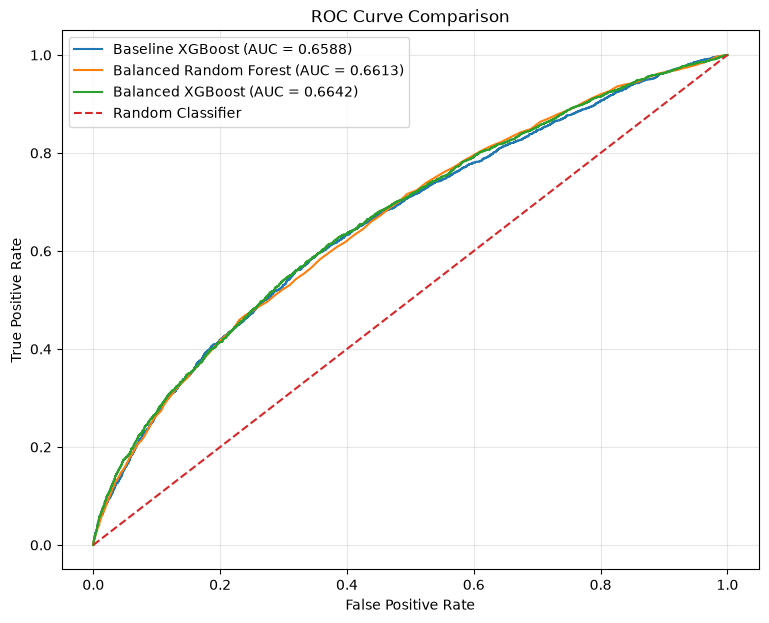

In [167]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_baseline, tpr_baseline, _ = roc_curve(
    y_test,
    y_prob_baseline_xgb
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_balanced_rf
)

fpr_balanced_xgb, tpr_balanced_xgb, _ = roc_curve(
    y_test,
    y_prob_balanced_xgb
)

# Calculate AUC
auc_baseline = roc_auc_score(y_test, y_prob_baseline_xgb)
auc_rf = roc_auc_score(y_test, y_prob_balanced_rf)
auc_balanced_xgb = roc_auc_score(y_test, y_prob_balanced_xgb)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"Baseline XGBoost (AUC = {auc_baseline:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Balanced Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_balanced_xgb,
    tpr_balanced_xgb,
    label=f"Balanced XGBoost (AUC = {auc_balanced_xgb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Precision–Recall Curve Comparison

The Precision–Recall curve evaluates the trade-off between precision and recall
across different classification thresholds.

For an imbalanced medical prediction problem, Precision–Recall analysis can be
more informative than ROC analysis because it focuses directly on the positive
class.

Average Precision (AP) summarizes the Precision–Recall curve.
Higher AP indicates better performance in identifying the positive class while
maintaining precision.

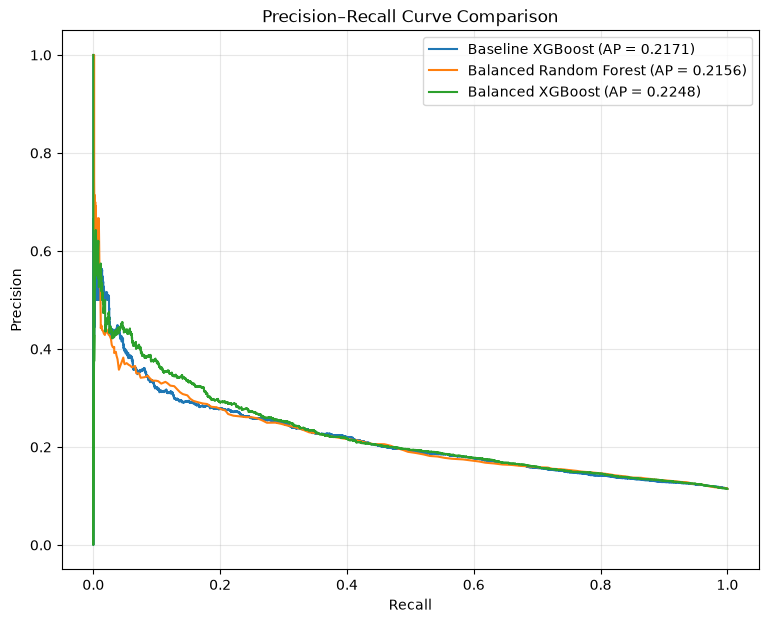

In [168]:
# ============================================================
# PRECISION-RECALL CURVE COMPARISON
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curves
precision_baseline, recall_baseline, _ = precision_recall_curve(
    y_test,
    y_prob_baseline_xgb
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_balanced_rf
)

precision_balanced_xgb, recall_balanced_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_balanced_xgb
)

# Calculate Average Precision
ap_baseline = average_precision_score(
    y_test,
    y_prob_baseline_xgb
)

ap_rf = average_precision_score(
    y_test,
    y_prob_balanced_rf
)

ap_balanced_xgb = average_precision_score(
    y_test,
    y_prob_balanced_xgb
)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(
    recall_baseline,
    precision_baseline,
    label=f"Baseline XGBoost (AP = {ap_baseline:.4f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Balanced Random Forest (AP = {ap_rf:.4f})"
)

plt.plot(
    recall_balanced_xgb,
    precision_balanced_xgb,
    label=f"Balanced XGBoost (AP = {ap_balanced_xgb:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# XGBoost Modeling & Model Comparison

## Objective

The objective of this phase was to build and compare machine learning models for
predicting **30-day hospital readmission**.

Because the target variable is imbalanced, accuracy alone is not sufficient for
model selection. The analysis therefore focuses primarily on:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Average Precision (AP)

Threshold optimization was performed using **Out-of-Fold (OOF) training
predictions** so that the test set remained completely untouched during
threshold selection.

---

## 1. Baseline XGBoost

The first model was a standard XGBoost classifier without class weighting.

### Model configuration

- `n_estimators = 100`
- `learning_rate = 0.1`
- `max_depth = 6`
- `subsample = 1.0`
- `colsample_bytree = 1.0`
- Default class weighting

### Threshold selection

The classification threshold was selected using OOF training predictions by
searching a predefined threshold range and selecting the threshold that
maximized F1 Score.

**Selected threshold: 0.14**

### Final Test Performance

| Metric | Score |
|---|---:|
| Accuracy | 0.7476 |
| Precision | 0.2088 |
| Recall | 0.4295 |
| F1 Score | 0.2810 |
| ROC-AUC | 0.6588 |
| Average Precision | 0.2171 |

### Confusion Matrix

- True Negatives (TN): 14,019
- False Positives (FP): 3,751
- False Negatives (FN): 1,315
- True Positives (TP): 990

The baseline XGBoost model achieved the highest F1 Score among the models
tested, although its recall was lower than the class-balanced models.

---

## 2. Balanced Random Forest

A class-balanced Random Forest was evaluated to provide a tree-based
alternative to XGBoost and to investigate whether class weighting could improve
detection of the minority class.

### Class balancing

The model used:

```python
class_weight="balanced"


---

# Markdown Cell 2 — Hyperparameter Tuning

This one should be a **plan/introductory section**, because we haven't actually tuned the model yet.

```markdown
# Hyperparameter Tuning — Balanced XGBoost

## Objective

The initial Balanced XGBoost model used a reasonable baseline configuration,
but its hyperparameters have not yet been optimized.

The objective of this phase is to determine whether systematic hyperparameter
tuning can improve the model's ability to identify patients at risk of
30-day readmission.

The current Balanced XGBoost model will be used as the starting point.

---

## Current Baseline Configuration

```python
XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=7.8421,
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Tuning — Balanced XGBoost

## Objective

The baseline Balanced XGBoost model achieved strong recall and the best
Average Precision among the evaluated candidate models.

The next step is to tune its hyperparameters using only the training data.

The test set remains completely untouched during hyperparameter tuning.

## Tuning Principles

We will focus on parameters that control:

- Model complexity
- Learning rate
- Number of trees
- Row sampling
- Feature sampling
- Minimum split requirements
- Regularization

Cross-validation will be used to compare candidate configurations.

The final test set will only be used once after the best configuration
has been selected.

## Primary Selection Metric

Because the project focuses on identifying patients at higher risk of
30-day readmission, Average Precision and recall-aware performance are
more informative than accuracy alone.

However, we will consider multiple metrics before selecting the final model.

In [169]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from xgboost import XGBClassifier

tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Tuning CV created.")



xgb_tuning_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    
    "model__learning_rate": [
        0.03,
        0.05,
        0.10
    ],
    
    "model__max_depth": [
        3,
        4,
        5,
        6
    ],
    
    "model__min_child_weight": [
        1,
        3,
        5
    ],
    
    "model__subsample": [
        0.7,
        0.8,
        1.0
    ],
    
    "model__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ]
}


#pipeline

tuned_xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_tuning_model)
])

print("Tuning pipeline created.")

Tuning CV created.
Tuning pipeline created.


In [170]:
random_search = RandomizedSearchCV(
    estimator=tuned_xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=tuning_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

random_search.fit(
    X_train,
    y_train
)

print("Randomized search completed.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Randomized search completed.


In [171]:
print("Best Average Precision:")
print(random_search.best_score_)

print("\nBest Parameters:")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

Best Average Precision:
0.23396808991202062

Best Parameters:
model__subsample: 0.8
model__n_estimators: 200
model__min_child_weight: 5
model__max_depth: 6
model__learning_rate: 0.05
model__colsample_bytree: 0.8


In [172]:
best_tuned_xgb = random_search.best_estimator_

print("\nBest tuned model selected.")


Best tuned model selected.


In [173]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

tuned_balanced_xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

print("Tuned Balanced XGBoost pipeline created.")

Tuned Balanced XGBoost pipeline created.


In [174]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

oof_prob_tuned_xgb = np.zeros(len(X_train))
oof_fold_tuned_xgb = np.full(len(X_train), -1)

tuned_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(
    tuned_cv.split(X_train, y_train),
    start=1
):
    fold_model = clone(tuned_balanced_xgb_pipeline)

    fold_model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx]
    )

    fold_prob = fold_model.predict_proba(
        X_train.iloc[val_idx]
    )[:, 1]

    oof_prob_tuned_xgb[val_idx] = fold_prob
    oof_fold_tuned_xgb[val_idx] = fold

    fold_roc_auc = roc_auc_score(
        y_train.iloc[val_idx],
        fold_prob
    )

    fold_ap = average_precision_score(
        y_train.iloc[val_idx],
        fold_prob
    )

    print(
        f"Fold {fold}: "
        f"ROC-AUC = {fold_roc_auc:.4f}, "
        f"AP = {fold_ap:.4f}"
    )

Fold 1: ROC-AUC = 0.6792, AP = 0.2310
Fold 2: ROC-AUC = 0.6829, AP = 0.2410
Fold 3: ROC-AUC = 0.6744, AP = 0.2361
Fold 4: ROC-AUC = 0.6659, AP = 0.2230
Fold 5: ROC-AUC = 0.6842, AP = 0.2334


In [175]:
print("\nOOF probability shape:", oof_prob_tuned_xgb.shape)
print("Training rows:", len(X_train))
print(
    "Missing OOF predictions:",
    np.isnan(oof_prob_tuned_xgb).sum()
)
print(
    "Rows without fold assignment:",
    (oof_fold_tuned_xgb == -1).sum()
)


OOF probability shape: (80039,)
Training rows: 80039
Missing OOF predictions: 0
Rows without fold assignment: 0


# Model Evaluation Utility

To keep model evaluation consistent across experiments, we use a reusable
function that calculates classification metrics and the confusion matrix
for a specified probability threshold.

In [176]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


def evaluate_model(
    model_name,
    y_true,
    y_prob,
    threshold
):
    """
    Evaluate a binary classification model at a given probability threshold.
    """

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "Average_Precision": average_precision_score(
            y_true,
            y_prob
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [177]:
print(
    evaluate_model(
        model_name="Tuned Balanced XGBoost",
        y_true=y_train,
        y_prob=oof_prob_tuned_xgb,
        threshold=0.50
    )
)

{'Model': 'Tuned Balanced XGBoost', 'Threshold': 0.5, 'Accuracy': 0.6824922850110571, 'Precision': 0.18924976258309592, 'Recall': 0.5503756076005303, 'F1': 0.2816519207394635, 'ROC_AUC': 0.6772065382120684, 'Average_Precision': 0.232282785235465, 'TN': np.int64(49644), 'FP': np.int64(21343), 'FN': np.int64(4070), 'TP': np.int64(4982)}


In [178]:
oof_roc_auc_tuned_xgb = roc_auc_score(
    y_train,
    oof_prob_tuned_xgb
)

oof_ap_tuned_xgb = average_precision_score(
    y_train,
    oof_prob_tuned_xgb
)

print("Tuned XGBoost OOF Performance")
print("=" * 50)
print(f"ROC-AUC:           {oof_roc_auc_tuned_xgb:.4f}")
print(f"Average Precision: {oof_ap_tuned_xgb:.4f}")

Tuned XGBoost OOF Performance
ROC-AUC:           0.6772
Average Precision: 0.2323


In [179]:
thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results_tuned_xgb = []

for threshold in thresholds:

    result = evaluate_model(
        model_name="Tuned Balanced XGBoost",
        y_true=y_train,
        y_prob=oof_prob_tuned_xgb,
        threshold=threshold
    )

    result["Positive_Predictions"] = (
        oof_prob_tuned_xgb >= threshold
    ).sum()

    threshold_results_tuned_xgb.append(result)

threshold_df_tuned_xgb = pd.DataFrame(
    threshold_results_tuned_xgb
)

threshold_df_tuned_xgb.sort_values(
    "F1",
    ascending=False
).head(10)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,TN,FP,FN,TP,Positive_Predictions
45,Tuned Balanced XGBoost,0.50,0.682492,0.189250,0.550376,0.281652,0.677207,0.232283,49644,21343,4070,4982,26325
44,Tuned Balanced XGBoost,0.49,0.663089,0.184990,0.581087,0.280638,0.677207,0.232283,47813,23174,3792,5260,28434
43,Tuned Balanced XGBoost,0.48,0.642937,0.179980,0.606606,0.277597,0.677207,0.232283,45969,25018,3561,5491,30509
42,Tuned Balanced XGBoost,0.47,0.622209,0.175221,0.631352,0.274311,0.677207,0.232283,44086,26901,3337,5715,32616
41,Tuned Balanced XGBoost,0.46,0.601944,0.170975,0.654662,0.271138,0.677207,0.232283,42253,28734,3126,5926,34660
40,Tuned Balanced XGBoost,0.45,0.581079,0.167292,0.679850,0.268511,0.677207,0.232283,40355,30632,2898,6154,36786
39,Tuned Balanced XGBoost,0.44,0.558703,0.162985,0.701723,0.264529,0.677207,0.232283,38366,32621,2700,6352,38973
38,Tuned Balanced XGBoost,0.43,0.537301,0.159504,0.724039,0.261418,0.677207,0.232283,36451,34536,2498,6554,41090
37,Tuned Balanced XGBoost,0.42,0.515361,0.156478,0.748232,0.258828,0.677207,0.232283,34476,36511,2279,6773,43284
36,Tuned Balanced XGBoost,0.41,0.493334,0.153233,0.768891,0.255539,0.677207,0.232283,32526,38461,2092,6960,45421


In [180]:
best_threshold_row_tuned_xgb = (
    threshold_df_tuned_xgb
    .sort_values("F1", ascending=False)
    .iloc[0]
)

best_threshold_tuned_xgb = (
    best_threshold_row_tuned_xgb["Threshold"]
)

print("=" * 70)
print("BEST OOF THRESHOLD")
print("MODEL: TUNED BALANCED XGBOOST")
print("OBJECTIVE: MAXIMIZE F1")
print("=" * 70)

print(
    f"Selected Threshold  : "
    f"{best_threshold_tuned_xgb:.2f}"
)

print(
    f"Accuracy            : "
    f"{best_threshold_row_tuned_xgb['Accuracy']:.4f}"
)

print(
    f"Precision           : "
    f"{best_threshold_row_tuned_xgb['Precision']:.4f}"
)

print(
    f"Recall              : "
    f"{best_threshold_row_tuned_xgb['Recall']:.4f}"
)

print(
    f"F1 Score            : "
    f"{best_threshold_row_tuned_xgb['F1']:.4f}"
)

print(
    f"Positive Predictions: "
    f"{int(best_threshold_row_tuned_xgb['Positive_Predictions']):,}"
)

BEST OOF THRESHOLD
MODEL: TUNED BALANCED XGBOOST
OBJECTIVE: MAXIMIZE F1
Selected Threshold  : 0.50
Accuracy            : 0.6825
Precision           : 0.1892
Recall              : 0.5504
F1 Score            : 0.2817
Positive Predictions: 26,325


In [181]:
final_tuned_xgb = clone(tuned_balanced_xgb_pipeline)

final_tuned_xgb.fit(
    X_train,
    y_train
)

print("Final tuned XGBoost trained on full training set.")

y_prob_final_tuned_xgb = final_tuned_xgb.predict_proba(
    X_test
)[:, 1]

print("Test probability shape:", y_prob_final_tuned_xgb.shape)
print("Test target shape:", y_test.shape)

final_tuned_xgb_results = evaluate_model(
    model_name="Tuned Balanced XGBoost",
    y_true=y_test,
    y_prob=y_prob_final_tuned_xgb,
    threshold=best_threshold_tuned_xgb
)

pd.DataFrame([final_tuned_xgb_results])

Final tuned XGBoost trained on full training set.
Test probability shape: (20075,)
Test target shape: (20075,)


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision,TN,FP,FN,TP
0,Tuned Balanced XGBoost,0.5,0.677609,0.188612,0.547505,0.280569,0.667608,0.230322,12341,5429,1043,1262


# 10. Model Validation Summary

## 10.1 Model Comparison

[final comparison table]

## 10.2 ROC-AUC and Precision-Recall Analysis

[ROC curve + PR curve interpretation]

## 10.3 Threshold Selection

[explain OOF-based threshold selection]

## 10.4 Final Model Selection

### Selected Model: Tuned Balanced XGBoost

[why this model was selected]

## 10.5 Final Test Performance

[final metrics + confusion matrix]

## 10.6 What the Results Mean

[interpret recall, precision, FN, FP, AP, ROC-AUC]

## 10.7 Why Accuracy Is Not the Primary Metric

[explain class imbalance]

## 10.8 Data Leakage Controls

[patient-level split, pipeline, OOF, untouched test]

## 10.9 Limitations of the Current Modeling Approach

[moderate discrimination, feature limitations,
StratifiedKFold vs patient-level CV limitation, etc.]

## 10.10 Key Findings

[short project-level conclusions]

## 10.11 Next Phase

The next phase will focus on:

1. Probability calibration
2. Error analysis
3. False-negative analysis
4. False-positive analysis
5. Feature importance
6. SHAP explainability
7. Feature-engineering opportunities
8. Patient-level historical features
9. Model retraining and comparison
10. Robustness validation

In [185]:
# Fit the final tuned pipeline on the complete training dataset

tuned_balanced_xgb_pipeline.fit(
    X_train,
    y_train
)

print("✓ Final Tuned Balanced XGBoost fitted successfully")

✓ Final Tuned Balanced XGBoost fitted successfully


In [186]:
import joblib

joblib.dump(
    tuned_balanced_xgb_pipeline,
    "../Models/tuned_balanced_xgb_pipeline.joblib"
)

['../Models/tuned_balanced_xgb_pipeline.joblib']

In [187]:
# Verify that the saved artifact is fitted and can generate predictions

loaded_model = joblib.load("../Models/tuned_balanced_xgb_pipeline.joblib")

test_prob_check = loaded_model.predict_proba(
    X_test.iloc[:5]
)[:, 1]

print("✓ Saved model verification successful")
print("Sample probabilities:")
print(test_prob_check)

✓ Saved model verification successful
Sample probabilities:
[0.41323242 0.44095704 0.6044575  0.25110158 0.35449353]
